<a href="https://colab.research.google.com/github/Yasmina3/CBRA-FYP/blob/main/calibrated_passive_static_to_timeseries_simulator_V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calibrated passive static-to-time-series simulator for CBRA thermography

This notebook implements the **simulator stage**, not classification.

Goal:

```text
static COMSOL 40-sensor sample
+ temporal dynamics calibrated from real passive CBRA recordings
= realistic passive 30-minute 40-sensor simulated time series
```

The generated data are validated using temporal/statistical similarity metrics, not AUC or sensitivity/specificity.

Scientific framing:

- COMSOL/Pennes provides the static spatial thermal baseline.
- Real CBRA passive recordings calibrate stabilization, drift, common-mode noise, sensor-specific noise, autocorrelation, and covariance.
- The simulator is an empirical calibrated temporal overlay, not a full transient physiological/Pennes solver.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0) Optional Colab Drive mount

In [ ]:
try:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
except Exception:
    print("Not running in Colab, or Drive unavailable. Continuing.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) Imports and configuration

In [ ]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Optional
import json, math, os, re, warnings, traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance, ks_2samp
from scipy.signal import savgol_filter

warnings.filterwarnings("default")
RNG = np.random.default_rng(20260427)


@dataclass
class SimulatorConfig:
    # Path handling
    user_defined_root: Optional[str] = None
    real_filename: str = "real_breast_level_timeseries_40sensors_cleaned_fullsessions.csv"
    comsol_filename: str = "COMSOL_simulated-data_rebuilt.csv"
    output_folder: str = "calibrated_passive_static_to_timeseries_outputs"

    # Real data schema from previous project notebooks
    time_col: str = "time_step"
    label_col: str = "breast_label"
    session_col: str = "test_ref"
    side_col: str = "side_array"
    patient_col: Optional[str] = None
    n_sensors: int = 40

    # Grounded cleaning limits
    physiological_min_c: float = 20.0
    physiological_max_c: float = 45.0
    strict_valid_low_c: float = 28.0
    strict_valid_high_c: float = 42.0
    min_steps_per_session: int = 30

    # Temporal grid
    output_time_steps: Optional[int] = None
    nominal_duration_minutes: float = 30.0
    early_fraction: float = 0.10
    late_fraction: float = 0.20

    # Temporal calibration
    min_abs_stabilization_amplitude_c: float = 0.03
    fallback_exponential_rate: float = 4.0
    max_abs_ar1_rho: float = 0.98
    sensor_noise_shrinkage_to_diag: float = 0.40
    simulator_noise_multiplier: float = 1.0
    simulator_drift_multiplier: float = 1.0

    # Static alignment
    static_alignment_mode: str = "mean_shift"  # "none", "mean_shift", "mean_std"
    condition_aware_calibration: bool = True
    min_sessions_per_condition_calibration: int = 8

    # Generation size
    samples_per_static_row: int = 1
    max_static_rows: Optional[int] = None
    random_static_sample: bool = False

    # Defect injection disabled by default: clean simulator first
    inject_defects: bool = False
    defect_value_c: float = 15.0
    defect_event_probability_per_session_sensor: float = 0.0
    defect_max_duration_fraction: float = 0.03

    # Graph for validation only
    radial_weight_factor_default: float = 1.5

    # Saving
    save_generated_csv_gz: bool = True
    save_generated_parquet_if_available: bool = True
    save_numpy_tensor: bool = True
    figure_dpi: int = 160


CFG = SimulatorConfig()


def save_json(obj: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    def conv(x):
        if isinstance(x, (np.integer,)):
            return int(x)
        if isinstance(x, (np.floating,)):
            return float(x)
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, Path):
            return str(x)
        if isinstance(x, (np.bool_,)):
            return bool(x)
        return x
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=conv)


def safe_corr(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3 or np.nanstd(a[m]) < 1e-12 or np.nanstd(b[m]) < 1e-12:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])


def lag1_autocorr(y) -> float:
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) < 3 or np.nanstd(y) < 1e-12:
        return np.nan
    return float(np.corrcoef(y[:-1], y[1:])[0, 1])


def linear_slope(y, x=None) -> float:
    y = np.asarray(y, dtype=float)
    if x is None:
        x = np.linspace(0, 1, len(y))
    else:
        x = np.asarray(x, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3 or np.nanstd(x[m]) < 1e-12:
        return np.nan
    return float(np.polyfit(x[m], y[m], 1)[0])


print(json.dumps(asdict(CFG), indent=2, default=str))

{
  "user_defined_root": null,
  "real_filename": "real_breast_level_timeseries_40sensors_cleaned_fullsessions.csv",
  "comsol_filename": "COMSOL_simulated-data_rebuilt.csv",
  "output_folder": "calibrated_passive_static_to_timeseries_outputs",
  "time_col": "time_step",
  "label_col": "breast_label",
  "session_col": "test_ref",
  "side_col": "side_array",
  "patient_col": null,
  "n_sensors": 40,
  "physiological_min_c": 20.0,
  "physiological_max_c": 45.0,
  "strict_valid_low_c": 28.0,
  "strict_valid_high_c": 42.0,
  "min_steps_per_session": 30,
  "output_time_steps": null,
  "nominal_duration_minutes": 30.0,
  "early_fraction": 0.1,
  "late_fraction": 0.2,
  "min_abs_stabilization_amplitude_c": 0.03,
  "fallback_exponential_rate": 4.0,
  "max_abs_ar1_rho": 0.98,
  "sensor_noise_shrinkage_to_diag": 0.4,
  "simulator_noise_multiplier": 1.0,
  "simulator_drift_multiplier": 1.0,
  "static_alignment_mode": "mean_shift",
  "condition_aware_calibration": true,
  "min_sessions_per_conditi

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2) Scientific grounding register

In [ ]:
SCIENTIFIC_GROUNDING = pd.DataFrame([
    {
        "element": "COMSOL 40-sensor static vectors",
        "status": "grounded in COMSOL/Pennes simulation paper",
        "use": "static spatial baseline T_static",
    },
    {
        "element": "Pennes equation",
        "status": "grounded physical model",
        "use": "physical justification for static COMSOL baseline only",
    },
    {
        "element": "30-minute passive acquisition",
        "status": "grounded in clinical CBRA report",
        "use": "temporal duration target",
    },
    {
        "element": "T < 20 C contact-loss threshold",
        "status": "grounded in clinical preprocessing",
        "use": "quality control and optional defect simulation",
    },
    {
        "element": "temporal overlay equation",
        "status": "empirical, calibrated from real CBRA data",
        "use": "main simulator model",
    },
    {
        "element": "AR(1) residual noise",
        "status": "empirical assumption fitted from real residual autocorrelation",
        "use": "sensor/common-mode noise generation",
    },
    {
        "element": "mean-shift static alignment",
        "status": "empirical calibration assumption",
        "use": "match real absolute temperature while preserving COMSOL spatial contrast",
    },
])
display(SCIENTIFIC_GROUNDING)

,element,status,use
0,COMSOL 40-sensor static vectors,grounded in COMSOL/Pennes simulation paper,static spatial baseline T_static
1,Pennes equation,grounded physical model,physical justification for static COMSOL basel...
2,30-minute passive acquisition,grounded in clinical CBRA report,temporal duration target
3,T < 20 C contact-loss threshold,grounded in clinical preprocessing,quality control and optional defect simulation
4,temporal overlay equation,"empirical, calibrated from real CBRA data",main simulator model
5,AR(1) residual noise,empirical assumption fitted from real residual...,sensor/common-mode noise generation
6,mean-shift static alignment,empirical calibration assumption,match real absolute temperature while preservi...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3) Locate files and create output folders

In [ ]:
REAL_ALIASES = [
    CFG.real_filename,
    "real_breast_level_timeseries_40sensors_cleaned_fullsessions.csv",
    "real_breast_level_timeseries_40sensors_cleaned.csv",
]
COMSOL_ALIASES = [
    CFG.comsol_filename,
    "COMSOL_simulated-data_rebuilt.csv",
    "COMSOL_simulated-data.csv",
    "breast_40_sensors_dataset(1).csv",
    "breast_40_sensors_dataset.csv",
]

def find_first(root: Path, names: list[str]) -> Optional[Path]:
    for name in names:
        p = root / name
        if p.exists():
            return p
    return None

def resolve_paths() -> tuple[Path, Path, Path]:
    candidates = []
    if CFG.user_defined_root:
        candidates.append(Path(CFG.user_defined_root))
    candidates += [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content/drive/MyDrive/clean-cbra"),
        Path("/content/drive/MyDrive"),
        Path("/mnt/data"),
    ]
    checked = []
    for root in candidates:
        root = root.expanduser().resolve()
        checked.append(str(root))
        real_path = find_first(root, REAL_ALIASES)
        comsol_path = find_first(root, COMSOL_ALIASES)
        if real_path is not None and comsol_path is not None:
            return root, real_path, comsol_path
    raise FileNotFoundError(
        "Could not find both real time-series and COMSOL/static files. "
        "Set CFG.user_defined_root manually. Checked: " + " | ".join(checked)
    )

ROOT, REAL_FULL_PATH, COMSOL_PATH = resolve_paths()

OUTPUT_DIR = ROOT / CFG.output_folder
AUDIT_DIR = OUTPUT_DIR / "00_data_audit"
CALIB_DIR = OUTPUT_DIR / "01_temporal_calibration"
GENERATED_DIR = OUTPUT_DIR / "02_generated_timeseries"
VALIDATION_DIR = OUTPUT_DIR / "03_validation"
FIG_DIR = OUTPUT_DIR / "04_figures"
TEST_DIR = OUTPUT_DIR / "05_tests"
CONFIG_DIR = OUTPUT_DIR / "config"

for d in [OUTPUT_DIR, AUDIT_DIR, CALIB_DIR, GENERATED_DIR, VALIDATION_DIR, FIG_DIR, TEST_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

save_json(asdict(CFG), CONFIG_DIR / "simulator_config.json")
SCIENTIFIC_GROUNDING.to_csv(CONFIG_DIR / "scientific_grounding_register.csv", index=False)

print("ROOT:", ROOT)
print("REAL_FULL_PATH:", REAL_FULL_PATH)
print("COMSOL_PATH:", COMSOL_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

ROOT: /content/drive/MyDrive/clean-cbra
REAL_FULL_PATH: /content/drive/MyDrive/clean-cbra/real_breast_level_timeseries_40sensors_cleaned_fullsessions.csv
COMSOL_PATH: /content/drive/MyDrive/clean-cbra/COMSOL_simulated-data_rebuilt.csv
OUTPUT_DIR: /content/drive/MyDrive/clean-cbra/calibrated_passive_static_to_timeseries_outputs


## 4) Load and standardize real + COMSOL data

In [ ]:
def detect_sensor_columns(df: pd.DataFrame, n=40) -> list[str]:
    names1 = [f"s_{i}" for i in range(1, n + 1)]
    names2 = [f"cg{i}" for i in range(1, n + 1)]
    names3 = [f"sensor_{i}" for i in range(1, n + 1)]
    for names in [names1, names2, names3]:
        if all(c in df.columns for c in names):
            return names
    candidates = []
    for c in df.columns:
        m = re.search(r"(\d+)$", str(c))
        if m and 1 <= int(m.group(1)) <= n:
            candidates.append((int(m.group(1)), c))
    candidates = sorted(candidates)
    if len(candidates) >= n:
        cols = [c for _, c in candidates[:n]]
        if len(set(cols)) == n:
            return cols
    raise ValueError(f"Could not detect {n} sensor columns.")

def standardize_sensor_names(df, cols, n=40):
    return df.rename(columns={old: f"s_{i}" for i, old in enumerate(cols, start=1)}).copy()

def normalize_label_value(x) -> str:
    mapping = {
        "Healthy": "Healthy", "healthy": "Healthy", "Normal": "Healthy", "normal": "Healthy",
        "Control": "Healthy", "control": "Healthy", "0": "Healthy", 0: "Healthy",
        "Tumor": "Tumor", "tumor": "Tumor", "Cancer": "Tumor", "cancer": "Tumor",
        "Anomalous": "Tumor", "anomalous": "Tumor", "1": "Tumor", 1: "Tumor",
    }
    return mapping.get(x, str(x))

def infer_patient_column(df):
    if CFG.patient_col and CFG.patient_col in df.columns:
        return CFG.patient_col
    for c in ["patient_id", "patient", "subject_id", "subject", "id_patient", "pat_id"]:
        if c in df.columns:
            return c
    return CFG.session_col

real_raw = pd.read_csv(REAL_FULL_PATH)
comsol_raw = pd.read_csv(COMSOL_PATH)

real_cols_orig = detect_sensor_columns(real_raw, CFG.n_sensors)
comsol_cols_orig = detect_sensor_columns(comsol_raw, CFG.n_sensors)

real_full = standardize_sensor_names(real_raw, real_cols_orig, CFG.n_sensors)
comsol = standardize_sensor_names(comsol_raw, comsol_cols_orig, CFG.n_sensors)
SENSOR_COLS = [f"s_{i}" for i in range(1, CFG.n_sensors + 1)]

PATIENT_COL = infer_patient_column(real_full)
required = [CFG.time_col, CFG.label_col, CFG.session_col, CFG.side_col] + SENSOR_COLS
missing = [c for c in required if c not in real_full.columns]
if missing:
    raise ValueError(f"Missing required real columns: {missing}")

real_full["patient_id__"] = real_full[PATIENT_COL].astype(str)
real_full["session_id__"] = real_full[CFG.session_col].astype(str)
real_full["side_id__"] = real_full[CFG.side_col].astype(str)
real_full[CFG.label_col] = real_full[CFG.label_col].map(normalize_label_value)
real_full = real_full[real_full[CFG.label_col].isin(["Healthy", "Tumor"])].copy()

for c in SENSOR_COLS:
    real_full[c] = pd.to_numeric(real_full[c], errors="coerce")
    comsol[c] = pd.to_numeric(comsol[c], errors="coerce")

if PATIENT_COL == CFG.session_col:
    warnings.warn("patient_id fell back to session_col/test_ref. Verify that this really identifies the patient/group.")

audit = {
    "real_shape": list(real_full.shape),
    "comsol_shape": list(comsol.shape),
    "patient_col_used": PATIENT_COL,
    "real_path": str(REAL_FULL_PATH),
    "comsol_path": str(COMSOL_PATH),
    "label_counts_rows": real_full[CFG.label_col].value_counts(dropna=False).to_dict(),
    "n_patient_groups": int(real_full["patient_id__"].nunique()),
    "n_sessions": int(real_full["session_id__"].nunique()),
}
save_json(audit, AUDIT_DIR / "data_audit_summary.json")
print(json.dumps(audit, indent=2))
display(real_full.head())
display(comsol.head())

{
  "real_shape": [
    53722,
    61
  ],
  "comsol_shape": [
    564,
    57
  ],
  "patient_col_used": "test_ref",
  "real_path": "/content/drive/MyDrive/clean-cbra/real_breast_level_timeseries_40sensors_cleaned_fullsessions.csv",
  "comsol_path": "/content/drive/MyDrive/clean-cbra/COMSOL_simulated-data_rebuilt.csv",
  "label_counts_rows": {
    "Healthy": 35080,
    "Tumor": 18642
  },
  "n_patient_groups": 46,
  "n_sessions": 46
}


/tmp/ipykernel_3439/2202042360.py:67: UserWarning: patient_id fell back to session_col/test_ref. Verify that this really identifies the patient/group.
  warnings.warn("patient_id fell back to session_col/test_ref. Verify that this really identifies the patient/group.")
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,test_ref,diagnostic,time_step,norm_ref,s_1,s_2,s_3,s_4,s_5,s_6,...,global_min_temp,QSI_defect_count,QSE_defect_count,QIE_defect_count,QII_defect_count,row_invalid_any_quadrant_gt2,total_defect_count,patient_id__,session_id__,side_id__
0,Test-patiente-01-37-WJ,1,1,patiente-1-37-wj,33.60,34.03,34.20,34.38,34.67,34.67,...,33.43,0,0,0,0,False,0,Test-patiente-01-37-WJ,Test-patiente-01-37-WJ,cg
1,Test-patiente-01-37-WJ,1,2,patiente-1-37-wj,33.59,34.03,34.20,34.45,34.68,34.70,...,33.41,0,0,0,0,False,0,Test-patiente-01-37-WJ,Test-patiente-01-37-WJ,cg
2,Test-patiente-01-37-WJ,1,3,patiente-1-37-wj,33.59,34.03,34.19,34.47,34.70,34.70,...,33.36,0,0,0,0,False,0,Test-patiente-01-37-WJ,Test-patiente-01-37-WJ,cg
3,Test-patiente-01-37-WJ,1,4,patiente-1-37-wj,33.59,34.02,34.20,34.48,34.71,34.70,...,33.34,0,0,0,0,False,0,Test-patiente-01-37-WJ,Test-patiente-01-37-WJ,cg
4,Test-patiente-01-37-WJ,1,5,patiente-1-37-wj,33.59,34.02,34.20,34.53,34.71,34.73,...,33.35,0,0,0,0,False,0,Test-patiente-01-37-WJ,Test-patiente-01-37-WJ,cg


,sample_id,source_file,relative_path,experiment_type,gland_size_mm,ambient_temp_c,condition,radius_mm,tumor_x,tumor_y,...,s_31,s_32,s_33,s_34,s_35,s_36,s_37,s_38,s_39,s_40
0,1,test_combi.txt,Generated Data/test_combi.txt,test_combi,NaN,NaN,NaN,NaN,NaN,NaN,...,35.244596,35.244572,35.244539,35.244535,35.244551,35.244564,35.244556,35.244520,35.244519,35.244495
1,2,test_combi.txt,Generated Data/test_combi.txt,test_combi,NaN,NaN,NaN,NaN,NaN,NaN,...,35.245117,35.245094,35.245061,35.245056,35.245072,35.245085,35.245077,35.245041,35.245041,35.245016
2,3,test_combi.txt,Generated Data/test_combi.txt,test_combi,NaN,NaN,NaN,NaN,NaN,NaN,...,35.245638,35.245615,35.245583,35.245578,35.245594,35.245607,35.245598,35.245563,35.245562,35.245538
3,4,test_combi.txt,Generated Data/test_combi.txt,test_combi,NaN,NaN,NaN,NaN,NaN,NaN,...,35.246159,35.246136,35.246104,35.246099,35.246115,35.246128,35.246119,35.246084,35.246083,35.246059
4,5,test_combi.txt,Generated Data/test_combi.txt,test_combi,NaN,NaN,NaN,NaN,NaN,NaN,...,35.246681,35.246657,35.246626,35.246620,35.246636,35.246649,35.246640,35.246605,35.246605,35.246580


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5) Clean real sessions and extract session-side matrices

In [ ]:
def robust_time_sort(g):
    out = g.copy()
    out[CFG.time_col] = pd.to_numeric(out[CFG.time_col], errors="coerce")
    return out.sort_values(CFG.time_col)

def physiological_clean_matrix(x):
    x = np.asarray(x, dtype=float).copy()
    invalid = (~np.isfinite(x)) | (x < CFG.physiological_min_c) | (x > CFG.physiological_max_c)
    report = {
        "n_invalid_values": int(invalid.sum()),
        "invalid_fraction": float(invalid.mean()),
    }
    x[invalid] = np.nan

    row_med = np.nanmedian(x, axis=1)
    for i in range(x.shape[0]):
        bad = ~np.isfinite(x[i])
        if bad.any() and np.isfinite(row_med[i]):
            x[i, bad] = row_med[i]

    col_med = np.nanmedian(x, axis=0)
    global_med = np.nanmedian(x)
    col_med[~np.isfinite(col_med)] = global_med
    inds = np.where(~np.isfinite(x))
    if len(inds[0]):
        x[inds] = np.take(col_med, inds[1])

    report["n_remaining_nan"] = int((~np.isfinite(x)).sum())
    return x, report

def extract_session_objects(df):
    rows = []
    matrices = {}
    qa = []
    group_cols = ["patient_id__", "session_id__", "side_id__"]

    for key, g in df.groupby(group_cols, sort=False):
        patient_id, session_id, side_id = key
        g = robust_time_sort(g)
        if len(g) < CFG.min_steps_per_session:
            qa.append({**dict(zip(group_cols, key)), "status": "too_short", "n_steps": len(g)})
            continue

        x_raw = g[SENSOR_COLS].to_numpy(dtype=float)
        x_clean, clean_report = physiological_clean_matrix(x_raw)

        label_values = g[CFG.label_col].dropna().unique()
        label = label_values[0] if len(label_values) else "Unknown"
        if len(label_values) > 1:
            qa.append({**dict(zip(group_cols, key)), "status": "mixed_labels", "labels": str(label_values)})

        mat_id = f"{patient_id}__{session_id}__{side_id}"
        matrices[mat_id] = {
            "X_raw": x_raw,
            "X": x_clean,
            "time": g[CFG.time_col].to_numpy(),
            "label": label,
            "patient_id": patient_id,
            "session_id": session_id,
            "side_id": side_id,
        }

        gm = np.nanmean(x_clean, axis=1)
        n = len(gm)
        early_n = max(3, int(round(CFG.early_fraction * n)))
        late_n = max(3, int(round(CFG.late_fraction * n)))

        rows.append({
            "matrix_id": mat_id,
            "patient_id": patient_id,
            "session_id": session_id,
            "side_id": side_id,
            "label": label,
            "n_steps": int(n),
            "early_global_mean": float(np.nanmean(gm[:early_n])),
            "late_global_mean": float(np.nanmean(gm[-late_n:])),
            "total_drift_late_minus_early": float(np.nanmean(gm[-late_n:]) - np.nanmean(gm[:early_n])),
            "global_slope_normtime": linear_slope(gm),
            "global_derivative_std": float(np.nanstd(np.diff(gm))) if n > 2 else np.nan,
            "global_lag1": lag1_autocorr(gm),
            **clean_report,
        })

    sessions = pd.DataFrame(rows)
    qa_df = pd.DataFrame(qa)
    if sessions.empty:
        raise ValueError("No valid session-side objects extracted.")

    sessions.to_csv(AUDIT_DIR / "real_session_side_audit.csv", index=False)
    if len(qa_df):
        qa_df.to_csv(AUDIT_DIR / "real_session_extraction_warnings.csv", index=False)
    return sessions, matrices, qa_df

real_sessions, real_matrices, extraction_qa = extract_session_objects(real_full)
display(real_sessions.head())
display(real_sessions["label"].value_counts(dropna=False))
display(real_sessions["n_steps"].describe())

save_json({
    "n_session_side_objects": int(len(real_sessions)),
    "n_groups": int(real_sessions["patient_id"].nunique()),
    "label_counts": real_sessions["label"].value_counts(dropna=False).to_dict(),
    "n_steps_summary": real_sessions["n_steps"].describe().to_dict(),
}, AUDIT_DIR / "session_extraction_summary.json")

/tmp/ipykernel_3439/3384183598.py:15: RuntimeWarning: All-NaN slice encountered
  row_med = np.nanmedian(x, axis=1)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_3439/3384183598.py:15: RuntimeWarning: All-NaN slice encountered
  row_med = np.nanmedian(x, axis=1)
/tmp/ipykernel_3439/3384183598.py:15: RuntimeWarning: All-NaN slice encountered
  row_med = np.nanmedian(x, axis=1)
/usr/local

,matrix_id,patient_id,session_id,side_id,label,n_steps,early_global_mean,late_global_mean,total_drift_late_minus_early,global_slope_normtime,global_derivative_std,global_lag1,n_invalid_values,invalid_fraction,n_remaining_nan
0,Test-patiente-01-37-WJ__Test-patiente-01-37-WJ...,Test-patiente-01-37-WJ,Test-patiente-01-37-WJ,cg,Tumor,574,34.734627,35.227402,0.492775,0.511701,0.016889,0.995399,0,0.0,0
1,Test-Patiente-01-38-JF__Test-Patiente-01-38-JF...,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF,cg,Tumor,551,34.880136,36.118255,1.238118,1.355118,0.002103,0.999995,0,0.0,0
2,Test_100_patiente_01-19-PM__Test_100_patiente_...,Test_100_patiente_01-19-PM,Test_100_patiente_01-19-PM,cg,Tumor,586,33.467500,34.833562,1.366062,1.423971,0.006806,0.999897,0,0.0,0
3,Test_103_patiente_01-20-GD__Test_103_patiente_...,Test_103_patiente_01-20-GD,Test_103_patiente_01-20-GD,cg,Healthy,585,32.106483,33.672669,1.566186,1.780863,0.001583,0.999998,0,0.0,0
4,Test_104_patiente_01-21-TC__Test_104_patiente_...,Test_104_patiente_01-21-TC,Test_104_patiente_01-21-TC,cg,Tumor,588,32.496123,34.190301,1.694178,1.790140,0.002905,0.999997,0,0.0,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count
label,
Healthy,60
Tumor,32


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,n_steps
count,92.000000
mean,583.934783
std,8.581611
min,551.000000
25%,581.000000
50%,585.000000
75%,587.000000
max,601.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6) Choose common temporal grid and resample real sessions

In [ ]:
def choose_output_time_steps():
    if CFG.output_time_steps is not None:
        return int(CFG.output_time_steps)
    return max(CFG.min_steps_per_session, int(round(float(real_sessions["n_steps"].median()))))

N_TIME = choose_output_time_steps()
T_NORM = np.linspace(0, 1, N_TIME)
EARLY_N = max(3, int(round(CFG.early_fraction * N_TIME)))
LATE_N = max(3, int(round(CFG.late_fraction * N_TIME)))
P_BASIS = T_NORM - np.mean(T_NORM[-LATE_N:])  # late-window mean zero

def resample_matrix(X, n_time=N_TIME):
    X = np.asarray(X, dtype=float)
    old_t = np.linspace(0, 1, X.shape[0])
    new_t = np.linspace(0, 1, n_time)
    out = np.empty((n_time, X.shape[1]), dtype=float)
    for j in range(X.shape[1]):
        y = X[:, j]
        m = np.isfinite(y)
        if m.sum() < 2:
            out[:, j] = np.nanmedian(y)
        else:
            out[:, j] = np.interp(new_t, old_t[m], y[m])
    return out

for obj in real_matrices.values():
    obj["X_resampled"] = resample_matrix(obj["X"], N_TIME)

print("N_TIME:", N_TIME, "| EARLY_N:", EARLY_N, "| LATE_N:", LATE_N)

N_TIME: 585 | EARLY_N: 58 | LATE_N: 117


## 7) COMSOL static anchor audit

{
  "n_static_rows": 564,
  "condition_col": "condition",
  "condition_counts": {
    "Tumor": 329,
    "Healthy": 228,
    "nan": 7
  },
  "static_global_mean_summary": {
    "count": 564.0,
    "mean": 35.06862134773138,
    "std": 0.3087894636468484,
    "min": 34.438858244476975,
    "25%": 34.93870781621833,
    "50%": 34.98778797203628,
    "75%": 35.19929498250389,
    "max": 36.39319887341288
  },
  "static_spatial_std_summary": {
    "count": 564.0,
    "mean": 0.28723477072789294,
    "std": 0.10327814368228154,
    "min": 0.10438949356649431,
    "25%": 0.24573766507406808,
    "50%": 0.2816823520563505,
    "75%": 0.3007220184774696,
    "max": 1.2116860927603332
  }
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


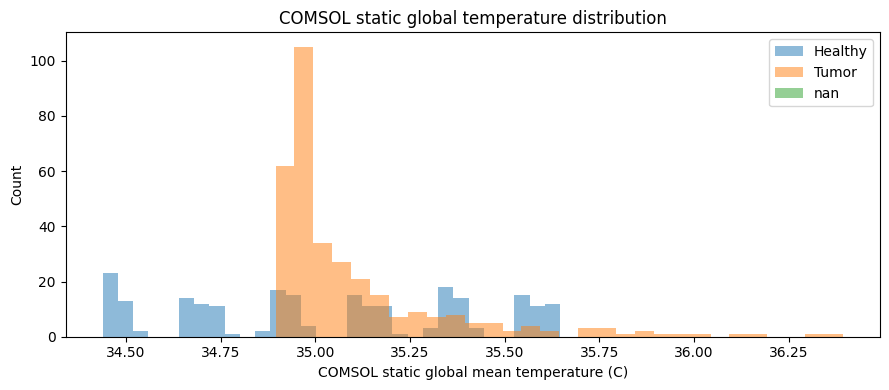

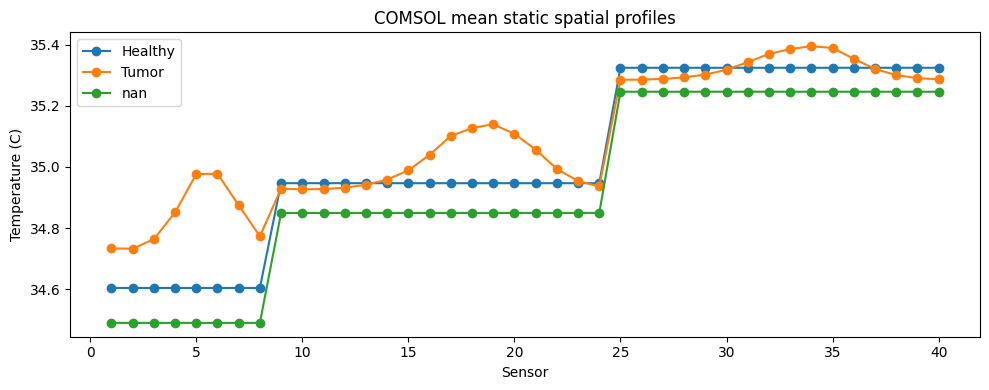

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def get_comsol_condition_col(df):
    for c in ["condition", "label", "class", "breast_label"]:
        if c in df.columns:
            return c
    return None

COMSOL_CONDITION_COL = get_comsol_condition_col(comsol)
if COMSOL_CONDITION_COL is not None:
    comsol["condition__"] = comsol[COMSOL_CONDITION_COL].map(normalize_label_value)
else:
    comsol["condition__"] = "Unknown"

mat = comsol[SENSOR_COLS].to_numpy(dtype=float)
if not np.isfinite(mat).all():
    warnings.warn("COMSOL contains invalid values; imputing by row median.")
    row_med = np.nanmedian(mat, axis=1)
    inds = np.where(~np.isfinite(mat))
    mat[inds] = np.take(row_med, inds[0])
    comsol.loc[:, SENSOR_COLS] = mat

comsol_audit = {
    "n_static_rows": int(len(comsol)),
    "condition_col": COMSOL_CONDITION_COL,
    "condition_counts": comsol["condition__"].value_counts(dropna=False).to_dict(),
    "static_global_mean_summary": pd.Series(np.nanmean(mat, axis=1)).describe().to_dict(),
    "static_spatial_std_summary": pd.Series(np.nanstd(mat, axis=1)).describe().to_dict(),
}
save_json(comsol_audit, AUDIT_DIR / "comsol_static_audit.json")
print(json.dumps(comsol_audit, indent=2))

plt.figure(figsize=(9,4))
for cond, g in comsol.groupby("condition__"):
    plt.hist(g[SENSOR_COLS].mean(axis=1), bins=30, alpha=0.5, label=str(cond))
plt.xlabel("COMSOL static global mean temperature (C)")
plt.ylabel("Count")
plt.title("COMSOL static global temperature distribution")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "comsol_static_global_mean_distribution.png", dpi=CFG.figure_dpi)
plt.show()

plt.figure(figsize=(10,4))
for cond, g in comsol.groupby("condition__"):
    plt.plot(range(1, CFG.n_sensors+1), g[SENSOR_COLS].mean(axis=0), marker="o", label=str(cond))
plt.xlabel("Sensor")
plt.ylabel("Temperature (C)")
plt.title("COMSOL mean static spatial profiles")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "comsol_static_mean_profiles.png", dpi=CFG.figure_dpi)
plt.show()

## 8) Calibrate passive temporal overlay

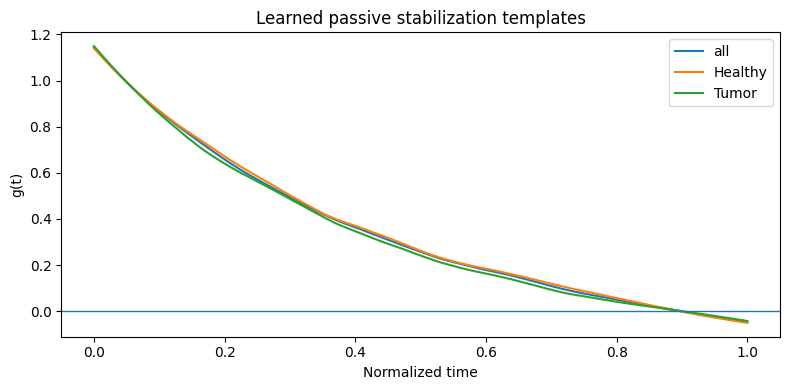

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count,mean,std,min,25%,50%,75%,max
A_stabilization,92.0,-1.371417e+00,6.235207e-01,-2.796851e+00,-1.837071e+00,-1.399817e+00,-8.617369e-01,-1.373221e-01
b_global_drift,92.0,3.711462e-02,4.606087e-01,-1.074529e+00,-2.665021e-01,-3.108222e-02,3.690364e-01,1.014188e+00
eta_rho,92.0,9.671169e-01,3.266799e-02,8.003061e-01,9.724571e-01,9.800000e-01,9.800000e-01,9.800000e-01
eta_innovation_sigma,92.0,5.028369e-03,6.418239e-03,5.343009e-04,1.337602e-03,2.815233e-03,5.751406e-03,4.367622e-02
late_global_mean,92.0,3.500388e+01,9.450896e-01,3.171857e+01,3.450479e+01,3.521726e+01,3.569615e+01,3.637674e+01
late_sensor_std,92.0,4.845206e-01,2.083529e-01,1.759435e-01,3.134286e-01,4.370509e-01,6.056434e-01,1.079022e+00
eps_rho_mean,92.0,9.593996e-01,1.945078e-02,8.677778e-01,9.538636e-01,9.653547e-01,9.718511e-01,9.792003e-01
eps_innovation_sigma_mean,92.0,1.017166e-02,8.517855e-03,3.393006e-03,5.470644e-03,7.298139e-03,1.070328e-02,5.442845e-02
d_sensor_mean,92.0,4.104329e-15,9.444220e-15,-1.705303e-14,-2.371714e-15,5.576095e-15,1.030287e-14,2.687850e-14
d_sensor_std,92.0,2.931592e-01,1.256840e-01,1.120534e-01,2.005719e-01,2.701743e-01,3.474501e-01,7.371281e-01


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def fallback_g_template():
    raw = np.exp(-CFG.fallback_exponential_rate * T_NORM)
    raw = raw - np.mean(raw[-LATE_N:])
    denom = np.mean(raw[:EARLY_N])
    if abs(denom) < 1e-12:
        denom = 1.0
    return raw / denom

def normalize_g_template(g):
    g = np.asarray(g, dtype=float).copy()
    if len(g) >= 21:
        win = min(len(g)//5*2+1, 101)
        win = max(5, win)
        if win % 2 == 0:
            win += 1
        try:
            g = savgol_filter(g, window_length=win, polyorder=2, mode="interp")
        except Exception:
            pass
    g = g - np.nanmean(g[-LATE_N:])
    denom = np.nanmean(g[:EARLY_N])
    if abs(denom) < 1e-12:
        return fallback_g_template()
    return g / denom

def build_template(matrix_ids):
    unit_curves, rows = [], []
    for mat_id in matrix_ids:
        X = real_matrices[mat_id]["X_resampled"]
        gm = np.nanmean(X, axis=1)
        y = gm - np.nanmean(gm[-LATE_N:])
        amp = float(np.nanmean(y[:EARLY_N]))
        rows.append({"matrix_id": mat_id, "raw_stabilization_amp_c": amp})
        if np.isfinite(amp) and abs(amp) >= CFG.min_abs_stabilization_amplitude_c:
            unit_curves.append(y / amp)

    if len(unit_curves) >= 5:
        g = np.nanmedian(np.vstack(unit_curves), axis=0)
        source = "real_median_unit_curves"
    else:
        g = fallback_g_template()
        source = "fallback_exponential"
    g = normalize_g_template(g)
    amp_df = pd.DataFrame(rows)
    amp_df["template_source"] = source
    return g, amp_df

def fit_global_components(gm, g_template):
    y = gm - np.nanmean(gm[-LATE_N:])
    design = np.column_stack([g_template, P_BASIS])
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    A, b = float(coef[0]), float(coef[1])
    det = A * g_template + b * P_BASIS
    eta = y - det
    return A, b, det, eta, y

def ar1_stats(y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) < 5 or np.nanstd(y) < 1e-12:
        return 0.0, 0.0
    rho = lag1_autocorr(y)
    if not np.isfinite(rho):
        rho = 0.0
    rho = float(np.clip(rho, -CFG.max_abs_ar1_rho, CFG.max_abs_ar1_rho))
    innov = y[1:] - rho * y[:-1]
    return rho, float(np.nanstd(innov))

def fit_sensor_components(X, det, eta):
    late_profile = np.nanmean(X[-LATE_N:, :], axis=0)
    Y = X - late_profile[None, :] - det[:, None] - eta[:, None]
    denom = float(np.dot(P_BASIS, P_BASIS))
    if denom < 1e-12:
        d = np.zeros(X.shape[1])
    else:
        d = (P_BASIS[:, None] * Y).sum(axis=0) / denom
    eps = Y - P_BASIS[:, None] * d[None, :]
    return late_profile, d, eps

def make_psd(cov):
    cov = np.asarray(cov, dtype=float)
    cov = np.nan_to_num((cov + cov.T) / 2, nan=0.0)
    vals, vecs = np.linalg.eigh(cov)
    vals = np.clip(vals, 1e-10, None)
    return (vecs * vals) @ vecs.T

def calibrate_group(matrix_ids, group_name):
    if len(matrix_ids) < 3:
        raise ValueError(f"Not enough sessions for group {group_name}")
    g_template, amp_df = build_template(matrix_ids)

    rows, d_vectors, eps_list, eta_list, late_profiles = [], [], [], [], []
    for mat_id in matrix_ids:
        obj = real_matrices[mat_id]
        X = obj["X_resampled"]
        gm = np.nanmean(X, axis=1)

        A, b, det, eta, y = fit_global_components(gm, g_template)
        late_profile, d_sensor, eps = fit_sensor_components(X, det, eta)
        eta_rho, eta_sigma = ar1_stats(eta)

        eps_rhos, eps_sigmas = [], []
        for j in range(CFG.n_sensors):
            r, s = ar1_stats(eps[:, j])
            eps_rhos.append(r)
            eps_sigmas.append(s)

        rows.append({
            "matrix_id": mat_id,
            "label": obj["label"],
            "patient_id": obj["patient_id"],
            "session_id": obj["session_id"],
            "side_id": obj["side_id"],
            "A_stabilization": A,
            "b_global_drift": b,
            "eta_rho": eta_rho,
            "eta_innovation_sigma": eta_sigma,
            "late_global_mean": float(np.nanmean(late_profile)),
            "late_sensor_std": float(np.nanstd(late_profile)),
            "eps_rho_mean": float(np.nanmean(eps_rhos)),
            "eps_innovation_sigma_mean": float(np.nanmean(eps_sigmas)),
            "d_sensor_mean": float(np.nanmean(d_sensor)),
            "d_sensor_std": float(np.nanstd(d_sensor)),
            "global_curve_rmse_after_fit": float(np.sqrt(np.nanmean((y - det) ** 2))),
        })
        d_vectors.append(d_sensor)
        eps_list.append(eps)
        eta_list.append(eta)
        late_profiles.append(late_profile)

    params_df = pd.DataFrame(rows)
    d_matrix = np.vstack(d_vectors)
    late_profiles = np.vstack(late_profiles)

    # Estimate sensor AR coefficients and innovation covariance.
    sensor_rho = []
    for j in range(CFG.n_sensors):
        rhos = []
        for eps in eps_list:
            r, _ = ar1_stats(eps[:, j])
            if np.isfinite(r):
                rhos.append(r)
        sensor_rho.append(float(np.nanmedian(rhos)) if rhos else 0.0)
    sensor_rho = np.clip(np.asarray(sensor_rho), -CFG.max_abs_ar1_rho, CFG.max_abs_ar1_rho)

    innovations = []
    for eps in eps_list:
        innovations.append(eps[1:, :] - eps[:-1, :] * sensor_rho[None, :])
    innov_stack = np.vstack(innovations)
    cov = np.cov(innov_stack, rowvar=False)
    diag = np.diag(np.diag(cov))
    cov = (1 - CFG.sensor_noise_shrinkage_to_diag) * cov + CFG.sensor_noise_shrinkage_to_diag * diag
    cov = make_psd(cov)

    cal = {
        "group_name": group_name,
        "matrix_ids": matrix_ids,
        "n_sessions": len(matrix_ids),
        "g_template": g_template,
        "amp_df": amp_df,
        "params_df": params_df,
        "d_matrix": d_matrix,
        "late_profiles": late_profiles,
        "sensor_rho": sensor_rho,
        "sensor_innovation_cov": cov,
        "eta_rhos": params_df["eta_rho"].dropna().to_numpy(dtype=float),
        "eta_sigmas": params_df["eta_innovation_sigma"].dropna().to_numpy(dtype=float),
        "eps_list": eps_list,
        "eta_list": eta_list,
    }
    return cal

all_ids = real_sessions["matrix_id"].tolist()
calibrations = {"all": calibrate_group(all_ids, "all")}

if CFG.condition_aware_calibration:
    for label, sub in real_sessions.groupby("label"):
        ids = sub["matrix_id"].tolist()
        if len(ids) >= CFG.min_sessions_per_condition_calibration:
            calibrations[str(label)] = calibrate_group(ids, str(label))
        else:
            print(f"Skipping condition-specific calibration for {label}: only {len(ids)} sessions")

for group_name, cal in calibrations.items():
    gd = CALIB_DIR / group_name
    gd.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"t_norm": T_NORM, "p_basis": P_BASIS, "g_template": cal["g_template"]}).to_csv(gd / "temporal_basis.csv", index=False)
    cal["amp_df"].to_csv(gd / "stabilization_amplitudes.csv", index=False)
    cal["params_df"].to_csv(gd / "calibrated_session_parameters.csv", index=False)
    np.save(gd / "d_sensor_matrix.npy", cal["d_matrix"])
    np.save(gd / "sensor_rho.npy", cal["sensor_rho"])
    np.save(gd / "sensor_innovation_cov.npy", cal["sensor_innovation_cov"])
    save_json({
        "group_name": group_name,
        "n_sessions": cal["n_sessions"],
        "A_summary": cal["params_df"]["A_stabilization"].describe().to_dict(),
        "b_summary": cal["params_df"]["b_global_drift"].describe().to_dict(),
        "eta_rho_summary": pd.Series(cal["eta_rhos"]).describe().to_dict(),
        "eta_sigma_summary": pd.Series(cal["eta_sigmas"]).describe().to_dict(),
        "late_global_mean_summary": cal["params_df"]["late_global_mean"].describe().to_dict(),
        "template_source_counts": cal["amp_df"]["template_source"].value_counts().to_dict(),
    }, gd / "calibration_summary.json")

plt.figure(figsize=(8,4))
for group_name, cal in calibrations.items():
    plt.plot(T_NORM, cal["g_template"], label=group_name)
plt.axhline(0, linewidth=1)
plt.xlabel("Normalized time")
plt.ylabel("g(t)")
plt.title("Learned passive stabilization templates")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "learned_stabilization_templates.png", dpi=CFG.figure_dpi)
plt.show()

display(calibrations["all"]["params_df"].describe().T)

## 9) Real validation target metrics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
matrix_id,92,92,Test-patiente-01-37-WJ__Test-patiente-01-37-WJ...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,92,2,Healthy,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_steps,92.0,NaN,NaN,NaN,585.0,0.0,585.0,585.0,585.0,585.0,585.0
late_global_mean,92.0,NaN,NaN,NaN,35.003881,0.94509,31.718573,34.504795,35.217263,35.696155,36.376745
early_global_mean,92.0,NaN,NaN,NaN,33.597645,1.214455,29.527091,33.178101,33.862479,34.389091,35.409867
total_drift_late_minus_early,92.0,NaN,NaN,NaN,1.406236,0.54941,0.322719,1.047394,1.383715,1.768562,2.530499
early_minus_late,92.0,NaN,NaN,NaN,-1.406236,0.54941,-2.530499,-1.768562,-1.383715,-1.047394,-0.322719
global_slope_normtime,92.0,NaN,NaN,NaN,1.512788,0.598222,0.363056,1.122927,1.432833,1.902016,2.74353
global_curve_std,92.0,NaN,NaN,NaN,0.456056,0.176557,0.108807,0.342738,0.441897,0.571612,0.82585
global_derivative_std,92.0,NaN,NaN,NaN,0.005688,0.00638,0.000732,0.002302,0.003401,0.006086,0.045166


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


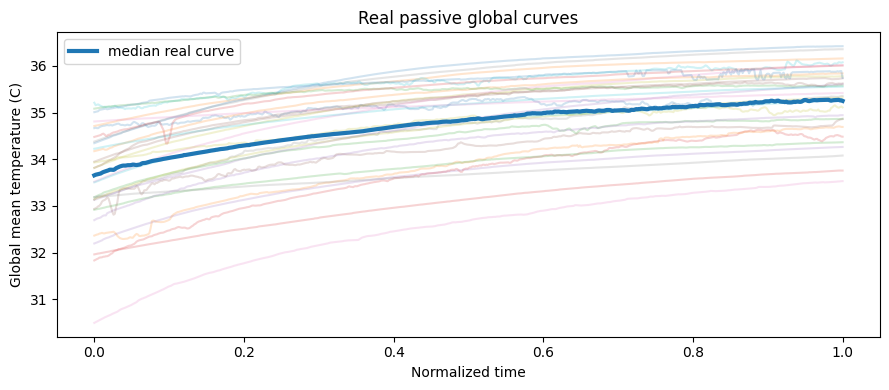

In [ ]:
def compute_session_metrics(X, label="", matrix_id=""):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    early_n = max(3, int(round(CFG.early_fraction * n)))
    late_n = max(3, int(round(CFG.late_fraction * n)))
    gm = np.nanmean(X, axis=1)
    late_profile = np.nanmean(X[-late_n:, :], axis=0)
    early_profile = np.nanmean(X[:early_n, :], axis=0)

    X_late_centered = X - late_profile[None, :]
    common = np.nanmean(X_late_centered, axis=1)
    residual = X_late_centered - common[:, None]

    try:
        corr = np.corrcoef(residual, rowvar=False)
        off = corr[np.triu_indices_from(corr, k=1)]
        corr_abs_mean = float(np.nanmean(np.abs(off)))
    except Exception:
        corr_abs_mean = np.nan

    sensor_lags = [lag1_autocorr(residual[:, j]) for j in range(X.shape[1])]

    return {
        "matrix_id": matrix_id,
        "label": label,
        "n_steps": int(n),
        "late_global_mean": float(np.nanmean(gm[-late_n:])),
        "early_global_mean": float(np.nanmean(gm[:early_n])),
        "total_drift_late_minus_early": float(np.nanmean(gm[-late_n:]) - np.nanmean(gm[:early_n])),
        "early_minus_late": float(np.nanmean(gm[:early_n]) - np.nanmean(gm[-late_n:])),
        "global_slope_normtime": linear_slope(gm),
        "global_curve_std": float(np.nanstd(gm)),
        "global_derivative_std": float(np.nanstd(np.diff(gm))) if n > 2 else np.nan,
        "global_lag1": lag1_autocorr(gm),
        "sensor_residual_std_mean": float(np.nanmean(np.nanstd(residual, axis=0))),
        "sensor_residual_std_median": float(np.nanmedian(np.nanstd(residual, axis=0))),
        "sensor_derivative_std_mean": float(np.nanmean(np.nanstd(np.diff(X, axis=0), axis=0))) if n > 2 else np.nan,
        "sensor_lag1_mean": float(np.nanmean(sensor_lags)),
        "late_spatial_std": float(np.nanstd(late_profile)),
        "early_spatial_std": float(np.nanstd(early_profile)),
        "inter_sensor_abs_corr_mean": corr_abs_mean,
        "pct_below_physiological_min": float(np.mean(X < CFG.physiological_min_c)),
        "pct_above_physiological_max": float(np.mean(X > CFG.physiological_max_c)),
        "pct_outside_strict_range": float(np.mean((X < CFG.strict_valid_low_c) | (X > CFG.strict_valid_high_c))),
    }

real_metric_rows, real_curves, real_corr_mats = [], [], []
for mat_id, obj in real_matrices.items():
    X = obj["X_resampled"]
    real_metric_rows.append(compute_session_metrics(X, label=obj["label"], matrix_id=mat_id))
    real_curves.append(np.nanmean(X, axis=1))

    late = np.nanmean(X[-LATE_N:, :], axis=0)
    res = X - late[None, :]
    res = res - np.nanmean(res, axis=1, keepdims=True)
    try:
        real_corr_mats.append(np.corrcoef(res, rowvar=False))
    except Exception:
        pass

real_metrics = pd.DataFrame(real_metric_rows)
real_metrics.to_csv(VALIDATION_DIR / "real_temporal_validation_metrics.csv", index=False)

REAL_MEDIAN_GLOBAL_CURVE = np.nanmedian(np.vstack(real_curves), axis=0)
REAL_MEAN_CORR = np.nanmean(np.stack(real_corr_mats), axis=0) if real_corr_mats else np.eye(CFG.n_sensors)
np.save(VALIDATION_DIR / "real_median_global_curve.npy", REAL_MEDIAN_GLOBAL_CURVE)
np.save(VALIDATION_DIR / "real_mean_sensor_correlation.npy", REAL_MEAN_CORR)

display(real_metrics.describe(include="all").T)

plt.figure(figsize=(9,4))
for curve in real_curves[:30]:
    plt.plot(T_NORM, curve, alpha=0.2)
plt.plot(T_NORM, REAL_MEDIAN_GLOBAL_CURVE, linewidth=3, label="median real curve")
plt.xlabel("Normalized time")
plt.ylabel("Global mean temperature (C)")
plt.title("Real passive global curves")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "real_global_curves_sample.png", dpi=CFG.figure_dpi)
plt.show()

## 10) Optional graph for spatial validation

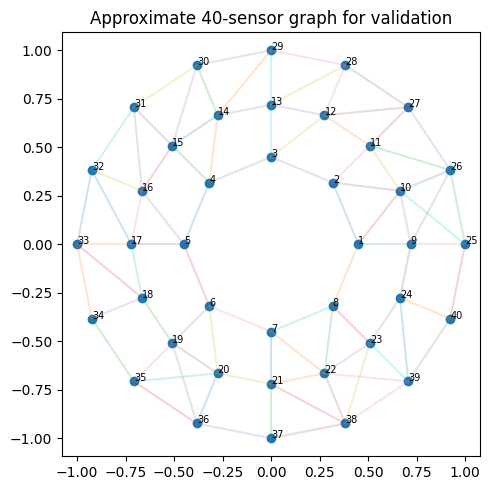

In [ ]:
def build_ring_radial_graph(n_sensors=40, radial_weight=1.5):
    ring_sizes = [8, 16, 16]
    if sum(ring_sizes) != n_sensors:
        raise ValueError("Default graph assumes 40 sensors.")
    coords = []
    radii = [0.45, 0.72, 1.0]
    for r_idx, size in enumerate(ring_sizes):
        for k in range(size):
            th = 2 * np.pi * k / size
            coords.append([radii[r_idx] * np.cos(th), radii[r_idx] * np.sin(th)])
    coords = np.asarray(coords)
    W = np.zeros((n_sensors, n_sensors))
    starts = np.cumsum([0] + ring_sizes)

    for r_idx, size in enumerate(ring_sizes):
        start = starts[r_idx]
        for k in range(size):
            i = start + k
            j = start + ((k + 1) % size)
            dist = np.linalg.norm(coords[i] - coords[j])
            W[i, j] = W[j, i] = 1.0 / max(dist, 1e-6)

    for r_idx in range(len(ring_sizes)-1):
        s1, e1 = starts[r_idx], starts[r_idx+1]
        s2, e2 = starts[r_idx+1], starts[r_idx+2]
        for i in range(s1, e1):
            dists = np.linalg.norm(coords[s2:e2] - coords[i], axis=1)
            for loc in np.argsort(dists)[:2]:
                j = s2 + loc
                dist = np.linalg.norm(coords[i] - coords[j])
                W[i, j] = W[j, i] = max(W[i, j], radial_weight / max(dist, 1e-6))

    D = np.diag(W.sum(axis=1))
    L = D - W
    return W, L, coords

W_GRAPH, L_GRAPH, GRAPH_COORDS = build_ring_radial_graph(CFG.n_sensors, CFG.radial_weight_factor_default)
np.save(CONFIG_DIR / "sensor_graph_W.npy", W_GRAPH)
np.save(CONFIG_DIR / "sensor_graph_L.npy", L_GRAPH)
pd.DataFrame(GRAPH_COORDS, columns=["x", "y"]).to_csv(CONFIG_DIR / "approx_sensor_graph_coordinates.csv", index=False)

assert np.allclose(W_GRAPH, W_GRAPH.T)
assert np.allclose(L_GRAPH.sum(axis=1), 0, atol=1e-9)

plt.figure(figsize=(5,5))
for i in range(CFG.n_sensors):
    for j in range(i+1, CFG.n_sensors):
        if W_GRAPH[i, j] > 0:
            plt.plot([GRAPH_COORDS[i,0], GRAPH_COORDS[j,0]], [GRAPH_COORDS[i,1], GRAPH_COORDS[j,1]], alpha=0.2)
plt.scatter(GRAPH_COORDS[:,0], GRAPH_COORDS[:,1])
for i, (x, y) in enumerate(GRAPH_COORDS, start=1):
    plt.text(x, y, str(i), fontsize=7)
plt.axis("equal")
plt.title("Approximate 40-sensor graph for validation")
plt.tight_layout()
plt.savefig(FIG_DIR / "approx_40_sensor_graph.png", dpi=CFG.figure_dpi)
plt.show()

## 11) Simulator functions

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11) Simulator functions — patched version
# Fixes:
#   1. spatial variance alignment using real late spatial std
#   2. less independent sensor noise
#   3. stronger temporal smoothness through AR(1) rho boosting
#   4. covariance recomputation at generation time
# ═══════════════════════════════════════════════════════════════════════════════

# Conservative second-stage defaults. These may be overwritten by the sweep cell.
CFG.static_alignment_mode = "mean_std"
CFG.sensor_noise_shrinkage_to_diag = 0.05
CFG.simulator_noise_multiplier = 0.65
CFG.simulator_drift_multiplier = 1.0

# Additional dynamic attributes, safe even if they were not in the original dataclass.
CFG.common_noise_multiplier = getattr(CFG, "common_noise_multiplier", 1.00)
CFG.spatial_scale_clip_low = getattr(CFG, "spatial_scale_clip_low", 0.50)
CFG.spatial_scale_clip_high = getattr(CFG, "spatial_scale_clip_high", 3.00)
CFG.sensor_rho_boost = getattr(CFG, "sensor_rho_boost", 0.50)
CFG.generation_rho_cap = getattr(CFG, "generation_rho_cap", 0.995)


def empirical_sample(arr, default=0.0, size=None):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return np.full(size, default) if size is not None else default
    idx = RNG.integers(0, len(arr), size=size)
    return arr[idx]


def get_calibration_for_condition(condition):
    condition = normalize_label_value(condition)
    if CFG.condition_aware_calibration and condition in calibrations:
        return calibrations[condition]
    return calibrations["all"]


def choose_static_rows(df):
    if CFG.max_static_rows is None or CFG.max_static_rows >= len(df):
        return df.copy()
    if CFG.random_static_sample:
        return df.sample(CFG.max_static_rows, random_state=20260427).copy()
    return df.iloc[:CFG.max_static_rows].copy()


def boost_sensor_rho(sensor_rho):
    """
    Increase temporal smoothness without inventing new physiology.
    This is an empirical generation adjustment, calibrated against real lag-1 statistics.
    """
    sensor_rho = np.asarray(sensor_rho, dtype=float)
    cap = float(getattr(CFG, "generation_rho_cap", 0.995))
    boost = float(getattr(CFG, "sensor_rho_boost", 0.0))

    boosted = sensor_rho.copy()
    positive = boosted > 0
    boosted[positive] = boosted[positive] + boost * (cap - boosted[positive])
    boosted = np.clip(boosted, -cap, cap)
    return boosted


def make_psd(cov):
    cov = np.nan_to_num((np.asarray(cov) + np.asarray(cov).T) / 2, nan=0.0)
    vals, vecs = np.linalg.eigh(cov)
    vals = np.clip(vals, 1e-10, None)
    return (vecs * vals) @ vecs.T


def recompute_generation_covariance(cal):
    """
    Recompute innovation covariance using the current shrinkage and rho settings.
    This avoids being stuck with the earlier over-diagonal covariance.
    """
    sensor_rho = boost_sensor_rho(cal["sensor_rho"])

    innovations = []
    for eps in cal["eps_list"]:
        eps = np.asarray(eps, dtype=float)
        if eps.shape[0] < 3:
            continue
        innovations.append(eps[1:, :] - eps[:-1, :] * sensor_rho[None, :])

    if len(innovations) == 0:
        cov = cal["sensor_innovation_cov"]
    else:
        innov_stack = np.vstack(innovations)
        cov = np.cov(innov_stack, rowvar=False)

    diag = np.diag(np.diag(cov))
    shrink = float(getattr(CFG, "sensor_noise_shrinkage_to_diag", 0.05))
    shrink = np.clip(shrink, 0.0, 1.0)
    cov = (1.0 - shrink) * cov + shrink * diag
    cov = make_psd(cov)

    cal["generation_sensor_rho"] = sensor_rho
    cal["generation_sensor_innovation_cov"] = cov
    return cal


def prepare_generation_calibrations():
    for key in calibrations:
        calibrations[key] = recompute_generation_covariance(calibrations[key])


def align_static_vector(static_vec, cal):
    """
    Align COMSOL static vector to real CBRA late-window distribution.

    Key correction:
    - previous mean_shift preserved COMSOL pattern but under-matched real spatial std.
    - mean_std alignment preserves COMSOL spatial shape while matching real spatial spread.
    """
    static_vec = np.asarray(static_vec, dtype=float)

    target_mean = float(empirical_sample(
        cal["params_df"]["late_global_mean"].to_numpy(),
        default=np.nanmean(static_vec)
    ))

    src_mean = float(np.nanmean(static_vec))
    src_std = float(np.nanstd(static_vec))
    mode = CFG.static_alignment_mode

    if mode == "none":
        aligned = static_vec.copy()
        offset, scale = 0.0, 1.0

    elif mode == "mean_shift":
        offset = target_mean - src_mean
        scale = 1.0
        aligned = static_vec + offset

    elif mode == "mean_std":
        target_std = float(empirical_sample(
            cal["params_df"]["late_sensor_std"].to_numpy(),
            default=src_std
        ))

        if src_std > 1e-12:
            raw_scale = target_std / src_std
        else:
            raw_scale = 1.0

        scale = float(np.clip(
            raw_scale,
            getattr(CFG, "spatial_scale_clip_low", 0.50),
            getattr(CFG, "spatial_scale_clip_high", 3.00)
        ))

        offset = target_mean - scale * src_mean
        aligned = scale * static_vec + offset

    else:
        raise ValueError(f"Unknown alignment mode: {mode}")

    return aligned, {
        "alignment_mode": mode,
        "source_static_mean": src_mean,
        "source_static_std": src_std,
        "target_late_global_mean": target_mean,
        "offset_applied": float(offset),
        "scale_applied": float(scale),
        "aligned_mean": float(np.nanmean(aligned)),
        "aligned_std": float(np.nanstd(aligned)),
    }


def generate_ar1_common(n_time, rho, sigma):
    rho = float(np.clip(rho, -CFG.generation_rho_cap, CFG.generation_rho_cap))
    sigma = max(0.0, float(sigma))
    sigma *= float(getattr(CFG, "common_noise_multiplier", 1.0))

    y = np.zeros(n_time)
    if sigma <= 0:
        return y

    innov = RNG.normal(0, sigma, size=n_time)
    for t in range(1, n_time):
        y[t] = rho * y[t - 1] + innov[t]

    return y - np.mean(y[-LATE_N:])


def generate_sensor_ar1(n_time, sensor_rho, cov):
    sensor_rho = boost_sensor_rho(sensor_rho)

    cov = make_psd(cov)
    cov = cov * (float(getattr(CFG, "simulator_noise_multiplier", 1.0)) ** 2)

    eps = np.zeros((n_time, CFG.n_sensors))
    innov = RNG.multivariate_normal(
        np.zeros(CFG.n_sensors),
        cov,
        size=n_time,
        method="svd"
    )

    for t in range(1, n_time):
        eps[t] = sensor_rho * eps[t - 1] + innov[t]

    return eps - np.mean(eps[-LATE_N:, :], axis=0, keepdims=True)


def maybe_inject_defects(X):
    X = np.asarray(X, dtype=float).copy()

    if not CFG.inject_defects:
        return X, {"defects_injected": 0, "defect_mode": "disabled"}

    max_len = max(1, int(round(CFG.defect_max_duration_fraction * X.shape[0])))
    n_events = 0

    for j in range(X.shape[1]):
        if RNG.random() < CFG.defect_event_probability_per_session_sensor:
            start = int(RNG.integers(0, max(1, X.shape[0] - max_len)))
            dur = int(RNG.integers(1, max_len + 1))
            X[start:start + dur, j] = CFG.defect_value_c
            n_events += 1

    return X, {
        "defects_injected": n_events,
        "defect_mode": "raw_contact_loss_values"
    }


def generate_one_timeseries(static_row, rep=0):
    condition = static_row.get("condition__", "Unknown")
    cal = get_calibration_for_condition(str(condition))

    static_vec = static_row[SENSOR_COLS].to_numpy(dtype=float)
    aligned_static, align_info = align_static_vector(static_vec, cal)

    prm = cal["params_df"].sample(
        n=1,
        replace=True,
        random_state=int(RNG.integers(0, 1_000_000_000))
    ).iloc[0]

    A = float(prm["A_stabilization"]) * CFG.simulator_drift_multiplier
    b = float(prm["b_global_drift"]) * CFG.simulator_drift_multiplier

    d_idx = int(RNG.integers(0, cal["d_matrix"].shape[0]))
    d_sensor = cal["d_matrix"][d_idx].astype(float) * CFG.simulator_drift_multiplier

    eta_rho = float(empirical_sample(cal["eta_rhos"], default=0.0))
    eta_sigma = float(empirical_sample(cal["eta_sigmas"], default=0.0))
    eta = generate_ar1_common(N_TIME, eta_rho, eta_sigma)

    sensor_rho = cal.get("generation_sensor_rho", boost_sensor_rho(cal["sensor_rho"]))
    sensor_cov = cal.get("generation_sensor_innovation_cov", cal["sensor_innovation_cov"])
    eps = generate_sensor_ar1(N_TIME, sensor_rho, sensor_cov)

    X = (
        aligned_static[None, :]
        + A * cal["g_template"][:, None]
        + b * P_BASIS[:, None]
        + d_sensor[None, :] * P_BASIS[:, None]
        + eta[:, None]
        + eps
    )

    X, defect_report = maybe_inject_defects(X)

    source_id = static_row.get("sample_id", static_row.name)
    generated_id = f"static_{source_id}_rep_{rep}"

    out = pd.DataFrame(X, columns=SENSOR_COLS)
    out.insert(0, "norm_time", T_NORM)
    out.insert(0, "time_step", np.arange(N_TIME))
    out.insert(0, "sim_rep", rep)
    out.insert(0, "source_static_id", source_id)
    out.insert(0, "generated_id", generated_id)
    out.insert(0, "condition", condition)

    meta_cols = [c for c in comsol.columns if c not in SENSOR_COLS and c != "condition__"]
    for c in meta_cols:
        out[c] = static_row.get(c, np.nan)

    info = {
        "generated_id": generated_id,
        "source_static_id": str(source_id),
        "condition": str(condition),
        "calibration_group": cal["group_name"],
        "rep": int(rep),
        "A_stabilization": A,
        "b_global_drift": b,
        "d_sensor_source_index": d_idx,
        "eta_rho": eta_rho,
        "eta_sigma": eta_sigma,
        **align_info,
        **defect_report,
    }

    return out, info, aligned_static


prepare_generation_calibrations()

print("Patched simulator functions ready.")
print("Current second-stage defaults:")
print({
    "static_alignment_mode": CFG.static_alignment_mode,
    "sensor_noise_shrinkage_to_diag": CFG.sensor_noise_shrinkage_to_diag,
    "simulator_noise_multiplier": CFG.simulator_noise_multiplier,
    "common_noise_multiplier": CFG.common_noise_multiplier,
    "sensor_rho_boost": CFG.sensor_rho_boost,
    "generation_rho_cap": CFG.generation_rho_cap,
    "spatial_scale_clip": [CFG.spatial_scale_clip_low, CFG.spatial_scale_clip_high],
})

Patched simulator functions ready.
Current second-stage defaults:
{'static_alignment_mode': 'mean_std', 'sensor_noise_shrinkage_to_diag': 0.05, 'simulator_noise_multiplier': 0.65, 'common_noise_multiplier': 1.0, 'sensor_rho_boost': 0.35, 'generation_rho_cap': 0.995, 'spatial_scale_clip': [0.5, 3.0]}


In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11A) Refinement: session-level smoothness/noise variability
# Purpose:
#   Previous version passed most checks but simulated sensor_lag1_mean was
#   slightly too high and too narrow across sessions.
#
# Scientific interpretation:
#   These are empirical generation variability knobs, calibrated from real CBRA
#   statistics. They are NOT physiological parameters.
# ═══════════════════════════════════════════════════════════════════════════════

CFG.use_session_variability = getattr(CFG, "use_session_variability", True)

# Absolute jitter around sensor_rho_boost, not relative.
CFG.sensor_rho_boost_jitter = getattr(CFG, "sensor_rho_boost_jitter", 0.0)

# Log-normal multiplicative jitter around simulator_noise_multiplier.
CFG.noise_multiplier_jitter = getattr(CFG, "noise_multiplier_jitter", 0.0)

# Log-normal multiplicative jitter around residual covariance scale.
CFG.covariance_scale_jitter = getattr(CFG, "covariance_scale_jitter", 0.0)

CFG.min_session_rho_boost = getattr(CFG, "min_session_rho_boost", 0.0)
CFG.max_session_rho_boost = getattr(CFG, "max_session_rho_boost", 0.60)

CFG.min_session_noise_multiplier = getattr(CFG, "min_session_noise_multiplier", 0.25)
CFG.max_session_noise_multiplier = getattr(CFG, "max_session_noise_multiplier", 0.90)

CFG.min_session_covariance_scale = getattr(CFG, "min_session_covariance_scale", 0.60)
CFG.max_session_covariance_scale = getattr(CFG, "max_session_covariance_scale", 1.40)


def sample_clipped_normal(base, jitter, low, high):
    base = float(base)
    jitter = float(jitter)
    if jitter <= 0:
        return float(np.clip(base, low, high))
    val = RNG.normal(base, jitter)
    return float(np.clip(val, low, high))


def sample_lognormal_multiplier(base, log_jitter, low, high):
    base = float(base)
    log_jitter = float(log_jitter)
    if log_jitter <= 0:
        return float(np.clip(base, low, high))
    val = base * float(np.exp(RNG.normal(0.0, log_jitter)))
    return float(np.clip(val, low, high))


def boost_sensor_rho(sensor_rho, boost=None, cap=None):
    """
    Apply AR(1) smoothness boost exactly once.
    In the previous implementation, some paths could effectively over-smooth.
    """
    sensor_rho = np.asarray(sensor_rho, dtype=float)

    if cap is None:
        cap = float(getattr(CFG, "generation_rho_cap", 0.995))
    if boost is None:
        boost = float(getattr(CFG, "sensor_rho_boost", 0.0))

    boosted = sensor_rho.copy()
    positive = boosted > 0
    boosted[positive] = boosted[positive] + float(boost) * (cap - boosted[positive])
    boosted = np.clip(boosted, -cap, cap)
    return boosted


def recompute_generation_covariance(cal):
    """
    Recompute innovation covariance using the current base rho boost.
    Session-level jitter is applied later during generation.
    """
    sensor_rho = boost_sensor_rho(
        cal["sensor_rho"],
        boost=float(getattr(CFG, "sensor_rho_boost", 0.0)),
        cap=float(getattr(CFG, "generation_rho_cap", 0.995)),
    )

    innovations = []
    for eps in cal["eps_list"]:
        eps = np.asarray(eps, dtype=float)
        if eps.shape[0] < 3:
            continue
        innovations.append(eps[1:, :] - eps[:-1, :] * sensor_rho[None, :])

    if len(innovations) == 0:
        cov = cal["sensor_innovation_cov"]
    else:
        innov_stack = np.vstack(innovations)
        cov = np.cov(innov_stack, rowvar=False)

    diag = np.diag(np.diag(cov))
    shrink = float(getattr(CFG, "sensor_noise_shrinkage_to_diag", 0.05))
    shrink = np.clip(shrink, 0.0, 1.0)

    cov = (1.0 - shrink) * cov + shrink * diag
    cov = make_psd(cov)

    cal["generation_sensor_rho"] = sensor_rho
    cal["generation_sensor_innovation_cov"] = cov
    return cal


def prepare_generation_calibrations():
    for key in calibrations:
        calibrations[key] = recompute_generation_covariance(calibrations[key])


def generate_sensor_ar1(
    n_time,
    sensor_rho_base,
    cov,
    session_rho_boost=None,
    session_noise_multiplier=None,
    session_covariance_scale=1.0,
):
    """
    Generate sensor-specific AR(1) residuals with optional session-level variability.
    This widens the lag-1 distribution across generated sessions.
    """
    if session_rho_boost is None:
        session_rho_boost = float(getattr(CFG, "sensor_rho_boost", 0.0))

    if session_noise_multiplier is None:
        session_noise_multiplier = float(getattr(CFG, "simulator_noise_multiplier", 1.0))

    sensor_rho = boost_sensor_rho(
        sensor_rho_base,
        boost=session_rho_boost,
        cap=float(getattr(CFG, "generation_rho_cap", 0.995)),
    )

    cov = make_psd(cov)
    cov = cov * (float(session_noise_multiplier) ** 2)
    cov = cov * float(session_covariance_scale)

    eps = np.zeros((n_time, CFG.n_sensors))
    innov = RNG.multivariate_normal(
        np.zeros(CFG.n_sensors),
        cov,
        size=n_time,
        method="svd",
    )

    for t in range(1, n_time):
        eps[t] = sensor_rho * eps[t - 1] + innov[t]

    return eps - np.mean(eps[-LATE_N:, :], axis=0, keepdims=True), sensor_rho


def generate_one_timeseries(static_row, rep=0):
    condition = static_row.get("condition__", "Unknown")
    cal = get_calibration_for_condition(str(condition))

    static_vec = static_row[SENSOR_COLS].to_numpy(dtype=float)
    aligned_static, align_info = align_static_vector(static_vec, cal)

    prm = cal["params_df"].sample(
        n=1,
        replace=True,
        random_state=int(RNG.integers(0, 1_000_000_000)),
    ).iloc[0]

    A = float(prm["A_stabilization"]) * CFG.simulator_drift_multiplier
    b = float(prm["b_global_drift"]) * CFG.simulator_drift_multiplier

    d_idx = int(RNG.integers(0, cal["d_matrix"].shape[0]))
    d_sensor = cal["d_matrix"][d_idx].astype(float) * CFG.simulator_drift_multiplier

    eta_rho = float(empirical_sample(cal["eta_rhos"], default=0.0))
    eta_sigma = float(empirical_sample(cal["eta_sigmas"], default=0.0))
    eta = generate_ar1_common(N_TIME, eta_rho, eta_sigma)

    # Session-specific empirical variability.
    if getattr(CFG, "use_session_variability", True):
        session_rho_boost = sample_clipped_normal(
            getattr(CFG, "sensor_rho_boost", 0.0),
            getattr(CFG, "sensor_rho_boost_jitter", 0.0),
            getattr(CFG, "min_session_rho_boost", 0.0),
            getattr(CFG, "max_session_rho_boost", 0.60),
        )

        session_noise_multiplier = sample_lognormal_multiplier(
            getattr(CFG, "simulator_noise_multiplier", 1.0),
            getattr(CFG, "noise_multiplier_jitter", 0.0),
            getattr(CFG, "min_session_noise_multiplier", 0.25),
            getattr(CFG, "max_session_noise_multiplier", 0.90),
        )

        session_covariance_scale = sample_lognormal_multiplier(
            1.0,
            getattr(CFG, "covariance_scale_jitter", 0.0),
            getattr(CFG, "min_session_covariance_scale", 0.60),
            getattr(CFG, "max_session_covariance_scale", 1.40),
        )
    else:
        session_rho_boost = float(getattr(CFG, "sensor_rho_boost", 0.0))
        session_noise_multiplier = float(getattr(CFG, "simulator_noise_multiplier", 1.0))
        session_covariance_scale = 1.0

    # Important: use base calibrated rho here, then apply boost exactly once.
    sensor_rho_base = cal["sensor_rho"]
    sensor_cov = cal.get("generation_sensor_innovation_cov", cal["sensor_innovation_cov"])

    eps, actual_sensor_rho = generate_sensor_ar1(
        N_TIME,
        sensor_rho_base,
        sensor_cov,
        session_rho_boost=session_rho_boost,
        session_noise_multiplier=session_noise_multiplier,
        session_covariance_scale=session_covariance_scale,
    )

    X = (
        aligned_static[None, :]
        + A * cal["g_template"][:, None]
        + b * P_BASIS[:, None]
        + d_sensor[None, :] * P_BASIS[:, None]
        + eta[:, None]
        + eps
    )

    X, defect_report = maybe_inject_defects(X)

    source_id = static_row.get("sample_id", static_row.name)
    generated_id = f"static_{source_id}_rep_{rep}"

    out = pd.DataFrame(X, columns=SENSOR_COLS)
    out.insert(0, "norm_time", T_NORM)
    out.insert(0, "time_step", np.arange(N_TIME))
    out.insert(0, "sim_rep", rep)
    out.insert(0, "source_static_id", source_id)
    out.insert(0, "generated_id", generated_id)
    out.insert(0, "condition", condition)

    meta_cols = [c for c in comsol.columns if c not in SENSOR_COLS and c != "condition__"]
    for c in meta_cols:
        out[c] = static_row.get(c, np.nan)

    info = {
        "generated_id": generated_id,
        "source_static_id": str(source_id),
        "condition": str(condition),
        "calibration_group": cal["group_name"],
        "rep": int(rep),
        "A_stabilization": A,
        "b_global_drift": b,
        "d_sensor_source_index": d_idx,
        "eta_rho": eta_rho,
        "eta_sigma": eta_sigma,
        "session_rho_boost": float(session_rho_boost),
        "session_noise_multiplier": float(session_noise_multiplier),
        "session_covariance_scale": float(session_covariance_scale),
        "actual_sensor_rho_mean": float(np.nanmean(actual_sensor_rho)),
        "actual_sensor_rho_std": float(np.nanstd(actual_sensor_rho)),
        **align_info,
        **defect_report,
    }

    return out, info, aligned_static


prepare_generation_calibrations()

print("Cell 11A refinement loaded.")
print({
    "use_session_variability": CFG.use_session_variability,
    "sensor_rho_boost_jitter": CFG.sensor_rho_boost_jitter,
    "noise_multiplier_jitter": CFG.noise_multiplier_jitter,
    "covariance_scale_jitter": CFG.covariance_scale_jitter,
})

Cell 11A refinement loaded.
{'use_session_variability': True, 'sensor_rho_boost_jitter': 0.0, 'noise_multiplier_jitter': 0.0, 'covariance_scale_jitter': 0.0}


In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11B) Refined second-stage calibration sweep v2
# Goal:
#   Preserve the good previous calibration while fixing the remaining warning:
#   sensor lag-1 was slightly too high and too narrowly distributed.
# ═══════════════════════════════════════════════════════════════════════════════

def temporarily_set_cfg(params):
    old = {}
    for k, v in params.items():
        old[k] = getattr(CFG, k, None)
        setattr(CFG, k, v)
    return old


def restore_cfg(old):
    for k, v in old.items():
        setattr(CFG, k, v)


def quick_generate_metrics(static_subset, n_reps=1):
    metric_rows = []

    for idx, row in static_subset.iterrows():
        for rep in range(n_reps):
            df_gen, info, aligned_static = generate_one_timeseries(row, rep=rep)
            X = df_gen[SENSOR_COLS].to_numpy(dtype=float)
            metric_rows.append(
                compute_session_metrics(
                    X,
                    label=str(info["condition"]),
                    matrix_id=info["generated_id"],
                )
            )

    return pd.DataFrame(metric_rows)


def distribution_stats(vals):
    vals = pd.Series(vals).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    if len(vals) == 0:
        return {"mean": np.nan, "std": np.nan, "p10": np.nan, "p90": np.nan}
    return {
        "mean": float(np.nanmean(vals)),
        "std": float(np.nanstd(vals)),
        "p10": float(np.nanpercentile(vals, 10)),
        "p90": float(np.nanpercentile(vals, 90)),
    }


def candidate_objective(sim_m):
    """
    Lower is better.

    This objective keeps the good previous targets:
      - spatial std
      - inter-sensor correlation
      - derivative std
      - residual std
      - total drift

    and adds stronger penalties for:
      - sensor_lag1_mean being too high
      - sensor_lag1_mean distribution being too narrow
    """
    targets = {
        "late_spatial_std": 2.0,
        "inter_sensor_abs_corr_mean": 2.0,
        "sensor_derivative_std_mean": 1.5,
        "sensor_residual_std_mean": 1.0,
        "total_drift_late_minus_early": 1.0,
        "global_derivative_std": 0.75,
    }

    score = 0.0
    parts = {}

    for metric, weight in targets.items():
        r = real_metrics[metric].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
        s = sim_m[metric].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)

        if len(r) == 0 or len(s) == 0:
            continue

        r_mean = float(np.nanmean(r))
        s_mean = float(np.nanmean(s))
        scale = abs(r_mean) + 1e-6

        rel_err = abs(s_mean - r_mean) / scale
        wd = wasserstein_distance(r, s) / (np.nanstd(r) + 1e-6)

        metric_score = weight * (rel_err + 0.25 * wd)
        score += metric_score

        parts[f"{metric}_real_mean"] = r_mean
        parts[f"{metric}_sim_mean"] = s_mean
        parts[f"{metric}_rel_error"] = rel_err
        parts[f"{metric}_wasserstein_scaled"] = wd
        parts[f"{metric}_score"] = metric_score

    # Focused lag-1 penalties.
    rlag = real_metrics["sensor_lag1_mean"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    slag = sim_m["sensor_lag1_mean"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)

    rstats = distribution_stats(rlag)
    sstats = distribution_stats(slag)

    if len(rlag) and len(slag):
        lag_mean_absdiff = abs(sstats["mean"] - rstats["mean"])
        lag_std_relerr = abs(sstats["std"] - rstats["std"]) / (rstats["std"] + 1e-6)
        lag_wd = wasserstein_distance(rlag, slag) / (np.nanstd(rlag) + 1e-6)

        # Strict because this was the only remaining warning.
        lag_score = 3.0 * (lag_mean_absdiff / 0.005) + 1.0 * lag_std_relerr + 0.5 * lag_wd
        score += lag_score

        parts.update({
            "sensor_lag1_real_mean": rstats["mean"],
            "sensor_lag1_sim_mean": sstats["mean"],
            "sensor_lag1_mean_absdiff": lag_mean_absdiff,
            "sensor_lag1_real_std": rstats["std"],
            "sensor_lag1_sim_std": sstats["std"],
            "sensor_lag1_std_relerr": lag_std_relerr,
            "sensor_lag1_wasserstein_scaled": lag_wd,
            "sensor_lag1_score": lag_score,
        })

    return float(score), parts


# Use a subset for fast tuning. Final generation still uses all static rows.
sweep_static_rows = choose_static_rows(comsol).reset_index(drop=True)
if len(sweep_static_rows) > 80:
    sweep_static_rows = sweep_static_rows.sample(80, random_state=20260427).reset_index(drop=True)

sweep_grid = []

# Focused grid around the previous best, but with lower rho boost options.
for noise_mult in [0.40, 0.45, 0.50, 0.55]:
    for shrink in [0.00, 0.05, 0.10]:
        for rho_boost in [0.00, 0.10, 0.20, 0.30, 0.35]:
            for rho_jitter in [0.00, 0.10, 0.18]:
                sweep_grid.append({
                    "static_alignment_mode": "mean_std",
                    "simulator_noise_multiplier": noise_mult,
                    "sensor_noise_shrinkage_to_diag": shrink,
                    "sensor_rho_boost": rho_boost,
                    "sensor_rho_boost_jitter": rho_jitter,
                    "noise_multiplier_jitter": 0.10 if rho_jitter > 0 else 0.00,
                    "covariance_scale_jitter": 0.10 if rho_jitter > 0 else 0.00,
                    "generation_rho_cap": 0.995,
                    "common_noise_multiplier": 1.0,
                    "spatial_scale_clip_low": 0.50,
                    "spatial_scale_clip_high": 3.00,
                    "use_session_variability": True,
                })

sweep_rows = []

print(f"Running refined simulator calibration sweep v2: {len(sweep_grid)} candidates on {len(sweep_static_rows)} static rows")

for k, params in enumerate(sweep_grid, start=1):
    old_cfg = temporarily_set_cfg(params)
    prepare_generation_calibrations()

    try:
        sim_m = quick_generate_metrics(sweep_static_rows, n_reps=1)
        score, parts = candidate_objective(sim_m)

        row = {
            "candidate_id": k,
            "objective": score,
            **params,
            **parts,
        }
        sweep_rows.append(row)

        print(
            f"[{k:03d}/{len(sweep_grid)}] score={score:.4f} "
            f"noise={params['simulator_noise_multiplier']} "
            f"shrink={params['sensor_noise_shrinkage_to_diag']} "
            f"rho_boost={params['sensor_rho_boost']} "
            f"rho_jitter={params['sensor_rho_boost_jitter']}"
        )

    except Exception as e:
        sweep_rows.append({
            "candidate_id": k,
            "objective": np.inf,
            **params,
            "error": repr(e),
        })
        print(f"[{k:03d}/{len(sweep_grid)}] ERROR:", repr(e))

    finally:
        restore_cfg(old_cfg)

sweep_df = pd.DataFrame(sweep_rows).sort_values("objective")
sweep_df.to_csv(VALIDATION_DIR / "second_stage_simulator_calibration_sweep_v2.csv", index=False)

display(sweep_df.head(15))

best = sweep_df.iloc[0].to_dict()

for key in [
    "static_alignment_mode",
    "simulator_noise_multiplier",
    "sensor_noise_shrinkage_to_diag",
    "sensor_rho_boost",
    "sensor_rho_boost_jitter",
    "noise_multiplier_jitter",
    "covariance_scale_jitter",
    "generation_rho_cap",
    "common_noise_multiplier",
    "spatial_scale_clip_low",
    "spatial_scale_clip_high",
    "use_session_variability",
]:
    setattr(CFG, key, best[key])

prepare_generation_calibrations()

selected = {
    k: getattr(CFG, k)
    for k in [
        "static_alignment_mode",
        "simulator_noise_multiplier",
        "sensor_noise_shrinkage_to_diag",
        "sensor_rho_boost",
        "sensor_rho_boost_jitter",
        "noise_multiplier_jitter",
        "covariance_scale_jitter",
        "generation_rho_cap",
        "common_noise_multiplier",
        "spatial_scale_clip_low",
        "spatial_scale_clip_high",
        "use_session_variability",
    ]
}

save_json({
    "selected_candidate": {
        "candidate_id": int(best["candidate_id"]),
        "objective": float(best["objective"]),
        **selected,
    },
    "lag1_fit": {
        "sensor_lag1_real_mean": float(best.get("sensor_lag1_real_mean", np.nan)),
        "sensor_lag1_sim_mean": float(best.get("sensor_lag1_sim_mean", np.nan)),
        "sensor_lag1_mean_absdiff": float(best.get("sensor_lag1_mean_absdiff", np.nan)),
        "sensor_lag1_real_std": float(best.get("sensor_lag1_real_std", np.nan)),
        "sensor_lag1_sim_std": float(best.get("sensor_lag1_sim_std", np.nan)),
        "sensor_lag1_std_relerr": float(best.get("sensor_lag1_std_relerr", np.nan)),
    },
    "scientific_note": (
        "These are empirical simulator calibration knobs selected to match real CBRA "
        "temporal/spatial statistics. They are not physiological parameters."
    )
}, VALIDATION_DIR / "selected_second_stage_simulator_config_v2.json")

print("Selected refined simulator calibration:")
print(json.dumps(selected, indent=2))

Running refined simulator calibration sweep v2: 180 candidates on 80 static rows


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[001/180] score=4.6729 noise=0.4 shrink=0.0 rho_boost=0.0 rho_jitter=0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[002/180] score=4.9560 noise=0.4 shrink=0.0 rho_boost=0.0 rho_jitter=0.1


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[180/180] score=3.9752 noise=0.55 shrink=0.1 rho_boost=0.35 rho_jitter=0.18


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,candidate_id,objective,static_alignment_mode,simulator_noise_multiplier,sensor_noise_shrinkage_to_diag,sensor_rho_boost,sensor_rho_boost_jitter,noise_multiplier_jitter,covariance_scale_jitter,generation_rho_cap,...,global_derivative_std_wasserstein_scaled,global_derivative_std_score,sensor_lag1_real_mean,sensor_lag1_sim_mean,sensor_lag1_mean_absdiff,sensor_lag1_real_std,sensor_lag1_sim_std,sensor_lag1_std_relerr,sensor_lag1_wasserstein_scaled,sensor_lag1_score
165,166,2.850211,mean_std,0.55,0.10,0.0,0.00,0.0,0.0,0.995,...,0.105451,0.078221,0.985847,0.987612,0.001765,0.011242,0.004187,0.627545,0.346816,1.859874
90,91,2.960373,mean_std,0.50,0.00,0.0,0.00,0.0,0.0,0.995,...,0.170562,0.087438,0.985847,0.988059,0.002212,0.011242,0.004223,0.624324,0.362211,2.132374
152,153,3.013503,mean_std,0.55,0.05,0.0,0.18,0.1,0.1,0.995,...,0.086115,0.024526,0.985847,0.987586,0.001739,0.011242,0.003825,0.659733,0.378456,1.892152
150,151,3.033454,mean_std,0.55,0.05,0.0,0.00,0.0,0.0,0.995,...,0.144020,0.056786,0.985847,0.988136,0.002289,0.011242,0.003985,0.645514,0.368346,2.203283
92,93,3.089186,mean_std,0.50,0.00,0.0,0.18,0.1,0.1,0.995,...,0.124518,0.069838,0.985847,0.988301,0.002454,0.011242,0.004196,0.626731,0.340771,2.269342
169,170,3.151846,mean_std,0.55,0.10,0.1,0.10,0.1,0.1,0.995,...,0.115025,0.047007,0.985847,0.987605,0.001758,0.011242,0.003648,0.675430,0.397069,1.928495
105,106,3.213975,mean_std,0.50,0.05,0.0,0.00,0.0,0.0,0.995,...,0.156594,0.070361,0.985847,0.988328,0.002481,0.011242,0.003995,0.644544,0.366792,2.316741
155,156,3.232013,mean_std,0.55,0.05,0.1,0.18,0.1,0.1,0.995,...,0.103025,0.027913,0.985847,0.988048,0.002200,0.011242,0.003548,0.684357,0.389043,2.199122
136,137,3.240955,mean_std,0.55,0.00,0.0,0.10,0.1,0.1,0.995,...,0.169081,0.050596,0.985847,0.987975,0.002127,0.011242,0.003771,0.664548,0.379678,2.130828
108,109,3.261319,mean_std,0.50,0.05,0.1,0.00,0.0,0.0,0.995,...,0.223400,0.096042,0.985847,0.988313,0.002465,0.011242,0.004462,0.603058,0.338039,2.251295


Selected refined simulator calibration:
{
  "static_alignment_mode": "mean_std",
  "simulator_noise_multiplier": 0.55,
  "sensor_noise_shrinkage_to_diag": 0.1,
  "sensor_rho_boost": 0.0,
  "sensor_rho_boost_jitter": 0.0,
  "noise_multiplier_jitter": 0.0,
  "covariance_scale_jitter": 0.0,
  "generation_rho_cap": 0.995,
  "common_noise_multiplier": 1.0,
  "spatial_scale_clip_low": 0.5,
  "spatial_scale_clip_high": 3.0,
  "use_session_variability": true
}


## 12) Generate calibrated passive time-series data

In [33]:
static_rows = choose_static_rows(comsol).reset_index(drop=True)
generated_frames = []
generation_info_rows = []
spatial_rows = []

expected_rows = len(static_rows) * CFG.samples_per_static_row * N_TIME
print(f"Generating {CFG.samples_per_static_row} replicate(s) for {len(static_rows)} static rows.")
print(f"Expected long rows: {expected_rows:,}")

for idx, row in static_rows.iterrows():
    for rep in range(CFG.samples_per_static_row):
        df_gen, info, aligned_static = generate_one_timeseries(row, rep=rep)
        generated_frames.append(df_gen)
        generation_info_rows.append(info)

        Xg = df_gen[SENSOR_COLS].to_numpy(dtype=float)
        late_mean = np.nanmean(Xg[-LATE_N:, :], axis=0)
        spatial_rows.append({
            "generated_id": info["generated_id"],
            "source_static_id": info["source_static_id"],
            "condition": info["condition"],
            "late_vs_aligned_static_corr": safe_corr(late_mean, aligned_static),
            "late_vs_aligned_static_rmse": float(np.sqrt(np.nanmean((late_mean - aligned_static) ** 2))),
            "aligned_static_std": float(np.nanstd(aligned_static)),
            "late_mean_std": float(np.nanstd(late_mean)),
        })
    if (idx + 1) % 100 == 0 or (idx + 1) == len(static_rows):
        print(f"  generated {idx + 1}/{len(static_rows)} static rows")

generated_long = pd.concat(generated_frames, ignore_index=True)
generation_info = pd.DataFrame(generation_info_rows)
spatial_preservation = pd.DataFrame(spatial_rows)

generation_info.to_csv(GENERATED_DIR / "generation_parameters_per_sample.csv", index=False)
spatial_preservation.to_csv(VALIDATION_DIR / "spatial_preservation_metrics.csv", index=False)

if CFG.save_generated_csv_gz:
    out_csv = GENERATED_DIR / "calibrated_passive_generated_timeseries_long.csv.gz"
    generated_long.to_csv(out_csv, index=False, compression="gzip")
    print("Saved:", out_csv)

if CFG.save_generated_parquet_if_available:
    try:
        out_pq = GENERATED_DIR / "calibrated_passive_generated_timeseries_long.parquet"
        generated_long.to_parquet(out_pq, index=False)
        print("Saved:", out_pq)
    except Exception as e:
        print("Parquet save skipped:", repr(e))

if CFG.save_numpy_tensor:
    unique_ids = generation_info["generated_id"].tolist()
    tensor = np.stack([
        generated_long.loc[generated_long["generated_id"] == gid, SENSOR_COLS].to_numpy(dtype=float)
        for gid in unique_ids
    ], axis=0)
    np.save(GENERATED_DIR / "generated_tensor_samples_time_sensors.npy", tensor)
    generation_info[["generated_id", "source_static_id", "condition", "calibration_group"]].to_csv(
        GENERATED_DIR / "generated_tensor_index.csv", index=False
    )
    print("Saved tensor:", tensor.shape)

print("generated_long shape:", generated_long.shape)
display(generated_long.head())
display(generation_info.head())
display(spatial_preservation.describe().T)

Generating 1 replicate(s) for 564 static rows.
Expected long rows: 329,940


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  generated 100/564 static rows


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  generated 200/564 static rows


...

,condition,generated_id,source_static_id,sim_rep,time_step,norm_time,s_1,s_2,s_3,s_4,...,radius_mm,tumor_x,tumor_y,tumor_z,parameter_signature,varying_parameters,fat_heat,gland_heat,tum_heat,t_r
0,NaN,static_1_rep_0,1,0,0,0.000000,33.114535,33.047049,33.027951,33.117380,...,NaN,NaN,NaN,NaN,"T (degC) @ t_r=3, tum_heat=1000","t_r,tum_heat",NaN,NaN,1000.0,3.0
1,NaN,static_1_rep_0,1,0,1,0.001712,33.137479,33.036528,33.032180,33.139433,...,NaN,NaN,NaN,NaN,"T (degC) @ t_r=3, tum_heat=1000","t_r,tum_heat",NaN,NaN,1000.0,3.0
2,NaN,static_1_rep_0,1,0,2,0.003425,33.127011,33.052450,33.043515,33.152205,...,NaN,NaN,NaN,NaN,"T (degC) @ t_r=3, tum_heat=1000","t_r,tum_heat",NaN,NaN,1000.0,3.0
3,NaN,static_1_rep_0,1,0,3,0.005137,33.138942,33.045989,33.052183,33.162559,...,NaN,NaN,NaN,NaN,"T (degC) @ t_r=3, tum_heat=1000","t_r,tum_heat",NaN,NaN,1000.0,3.0
4,NaN,static_1_rep_0,1,0,4,0.006849,33.134381,33.081149,33.061153,33.178139,...,NaN,NaN,NaN,NaN,"T (degC) @ t_r=3, tum_heat=1000","t_r,tum_heat",NaN,NaN,1000.0,3.0


,generated_id,source_static_id,condition,calibration_group,rep,A_stabilization,b_global_drift,d_sensor_source_index,eta_rho,eta_sigma,...,alignment_mode,source_static_mean,source_static_std,target_late_global_mean,offset_applied,scale_applied,aligned_mean,aligned_std,defects_injected,defect_mode
0,static_1_rep_0,1,nan,all,0,-2.134631,-0.325151,43,0.971763,0.001216,...,mean_std,34.933475,0.286298,35.732586,3.505069,0.922540,35.732586,0.264121,0,disabled
1,static_2_rep_0,2,nan,all,0,-2.099683,-0.756832,16,0.980000,0.001251,...,mean_std,34.934347,0.285930,35.246233,-7.211916,1.215370,35.246233,0.347510,0,disabled
2,static_3_rep_0,3,nan,all,0,-2.000533,-1.074529,59,0.980000,0.009508,...,mean_std,34.935219,0.285562,32.897912,-31.198795,1.834730,32.897912,0.523928,0,disabled
3,static_4_rep_0,4,nan,all,0,-0.572172,0.096377,17,0.980000,0.002166,...,mean_std,34.936091,0.285193,34.629398,-47.755194,2.358151,34.629398,0.672529,0,disabled
4,static_5_rep_0,5,nan,all,0,-1.547143,0.193601,18,0.980000,0.000534,...,mean_std,34.936963,0.284825,35.412313,13.024474,0.640807,35.412313,0.182518,0,disabled


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count,mean,std,min,25%,50%,75%,max
late_vs_aligned_static_corr,564.0,1.000000e+00,1.534123e-16,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
late_vs_aligned_static_rmse,564.0,9.682151e-15,1.134157e-15,6.833781e-15,8.917241e-15,9.664426e-15,1.041860e-14,1.389652e-14
aligned_static_std,564.0,4.571168e-01,1.820060e-01,1.759435e-01,3.048713e-01,4.283091e-01,5.786937e-01,1.032421e+00
late_mean_std,564.0,4.571168e-01,1.820060e-01,1.759435e-01,3.048713e-01,4.283091e-01,5.786937e-01,1.032421e+00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13) Validate simulated vs real temporal behavior

In [34]:
sim_metric_rows, sim_curves, sim_corr_mats = [], [], []

for gid, g in generated_long.groupby("generated_id", sort=False):
    X = g[SENSOR_COLS].to_numpy(dtype=float)
    cond = str(g["condition"].iloc[0])
    sim_metric_rows.append(compute_session_metrics(X, label=cond, matrix_id=gid))
    sim_curves.append(np.nanmean(X, axis=1))

    late = np.nanmean(X[-LATE_N:, :], axis=0)
    res = X - late[None, :]
    res = res - np.nanmean(res, axis=1, keepdims=True)
    try:
        sim_corr_mats.append(np.corrcoef(res, rowvar=False))
    except Exception:
        pass

sim_metrics = pd.DataFrame(sim_metric_rows)
sim_metrics.to_csv(VALIDATION_DIR / "simulated_temporal_validation_metrics.csv", index=False)

SIM_MEDIAN_GLOBAL_CURVE = np.nanmedian(np.vstack(sim_curves), axis=0)
SIM_MEAN_CORR = np.nanmean(np.stack(sim_corr_mats), axis=0) if sim_corr_mats else np.eye(CFG.n_sensors)
np.save(VALIDATION_DIR / "simulated_median_global_curve.npy", SIM_MEDIAN_GLOBAL_CURVE)
np.save(VALIDATION_DIR / "simulated_mean_sensor_correlation.npy", SIM_MEAN_CORR)

METRICS_TO_COMPARE = [
    "late_global_mean",
    "total_drift_late_minus_early",
    "early_minus_late",
    "global_slope_normtime",
    "global_curve_std",
    "global_derivative_std",
    "global_lag1",
    "sensor_residual_std_mean",
    "sensor_derivative_std_mean",
    "sensor_lag1_mean",
    "late_spatial_std",
    "inter_sensor_abs_corr_mean",
    "pct_outside_strict_range",
]

rows = []
for metric in METRICS_TO_COMPARE:
    r = real_metrics[metric].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    s = sim_metrics[metric].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    if len(r) == 0 or len(s) == 0:
        continue
    ks = ks_2samp(r, s)
    rows.append({
        "metric": metric,
        "real_mean": float(np.nanmean(r)),
        "sim_mean": float(np.nanmean(s)),
        "abs_mean_diff": float(abs(np.nanmean(r) - np.nanmean(s))),
        "real_std": float(np.nanstd(r)),
        "sim_std": float(np.nanstd(s)),
        "std_ratio_sim_over_real": float(np.nanstd(s) / np.nanstd(r)) if np.nanstd(r) > 1e-12 else np.nan,
        "wasserstein": float(wasserstein_distance(r, s)),
        "ks_statistic": float(ks.statistic),
        "ks_pvalue": float(ks.pvalue),
        "real_median": float(np.nanmedian(r)),
        "sim_median": float(np.nanmedian(s)),
    })

validation_comparison = pd.DataFrame(rows)
validation_comparison.to_csv(VALIDATION_DIR / "real_vs_simulated_metric_distribution_comparison.csv", index=False)

real_centered = REAL_MEDIAN_GLOBAL_CURVE - np.nanmean(REAL_MEDIAN_GLOBAL_CURVE[-LATE_N:])
sim_centered = SIM_MEDIAN_GLOBAL_CURVE - np.nanmean(SIM_MEDIAN_GLOBAL_CURVE[-LATE_N:])
curve_rmse = float(np.sqrt(np.nanmean((real_centered - sim_centered) ** 2)))
curve_corr = safe_corr(real_centered, sim_centered)

corr_diff = np.nan_to_num(REAL_MEAN_CORR - SIM_MEAN_CORR, nan=0.0)
corr_frob = float(np.linalg.norm(corr_diff, ord="fro") / CFG.n_sensors)

sensor_vals = generated_long[SENSOR_COLS].to_numpy(dtype=float)
validation_summary = {
    "n_real_sessions": int(len(real_metrics)),
    "n_simulated_sessions": int(len(sim_metrics)),
    "n_generated_long_rows": int(len(generated_long)),
    "global_curve_centered_rmse": curve_rmse,
    "global_curve_centered_corr": curve_corr,
    "sensor_correlation_matrix_frobenius_per_sensor": corr_frob,
    "median_spatial_preservation_corr": float(spatial_preservation["late_vs_aligned_static_corr"].median()),
    "median_spatial_preservation_rmse": float(spatial_preservation["late_vs_aligned_static_rmse"].median()),
    "pct_generated_below_20C": float((sensor_vals < CFG.physiological_min_c).mean()),
    "pct_generated_above_45C": float((sensor_vals > CFG.physiological_max_c).mean()),
    "pct_generated_outside_strict_range": float(((sensor_vals < CFG.strict_valid_low_c) | (sensor_vals > CFG.strict_valid_high_c)).mean()),
}
save_json(validation_summary, VALIDATION_DIR / "validation_summary.json")

print(json.dumps(validation_summary, indent=2))
display(validation_comparison.sort_values("wasserstein"))

{
  "n_real_sessions": 92,
  "n_simulated_sessions": 564,
  "n_generated_long_rows": 329940,
  "global_curve_centered_rmse": 0.033407808275951766,
  "global_curve_centered_corr": 0.998737975332833,
  "sensor_correlation_matrix_frobenius_per_sensor": 0.07710523239401895,
  "median_spatial_preservation_corr": 1.0,
  "median_spatial_preservation_rmse": 9.664426065637203e-15,
  "pct_generated_below_20C": 0.0,
  "pct_generated_above_45C": 0.0,
  "pct_generated_outside_strict_range": 0.0
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,metric,real_mean,sim_mean,abs_mean_diff,real_std,sim_std,std_ratio_sim_over_real,wasserstein,ks_statistic,ks_pvalue,real_median,sim_median
12,pct_outside_strict_range,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,1.000000e+00,0.000000,0.000000
6,global_lag1,0.999650,0.999761,0.000110,0.001166,0.000897,0.769595,0.000146,0.149399,5.210683e-02,0.999979,0.999971
5,global_derivative_std,0.005688,0.005813,0.000125,0.006345,0.005967,0.940359,0.000379,0.083102,6.119587e-01,0.003401,0.003755
8,sensor_derivative_std_mean,0.010827,0.011211,0.000384,0.009085,0.004789,0.527089,0.003227,0.530836,3.874888e-21,0.007636,0.009724
9,sensor_lag1_mean,0.985847,0.987806,0.001959,0.011242,0.004011,0.356753,0.004072,0.214385,1.132233e-03,0.988695,0.988500
4,global_curve_std,0.456056,0.453018,0.003038,0.175595,0.171517,0.976777,0.009271,0.046716,9.916018e-01,0.441897,0.444094
7,sensor_residual_std_mean,0.093488,0.084780,0.008708,0.035702,0.028388,0.795128,0.010013,0.194110,4.340740e-03,0.089428,0.079839
10,late_spatial_std,0.484521,0.457117,0.027404,0.207217,0.181845,0.877555,0.027453,0.054810,9.593997e-01,0.437051,0.428309
2,early_minus_late,-1.406236,-1.391847,0.014390,0.546416,0.534940,0.978998,0.030242,0.054579,9.607964e-01,-1.383715,-1.368343
1,total_drift_late_minus_early,1.406236,1.391847,0.014390,0.546416,0.534940,0.978998,0.030242,0.054579,9.607964e-01,1.383715,1.368343


## 14) Visual validation

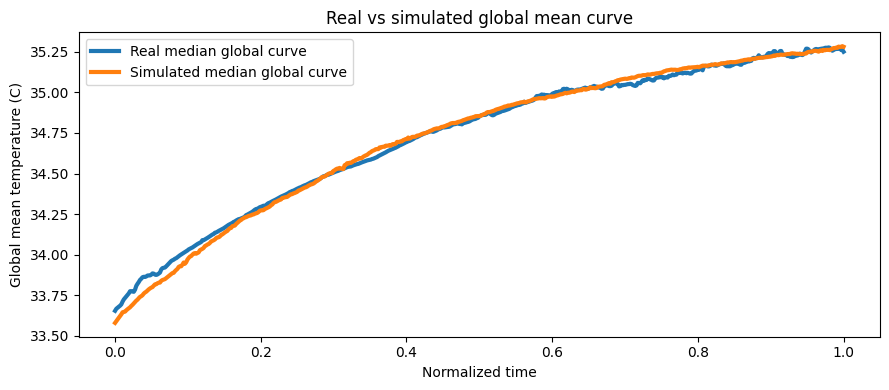

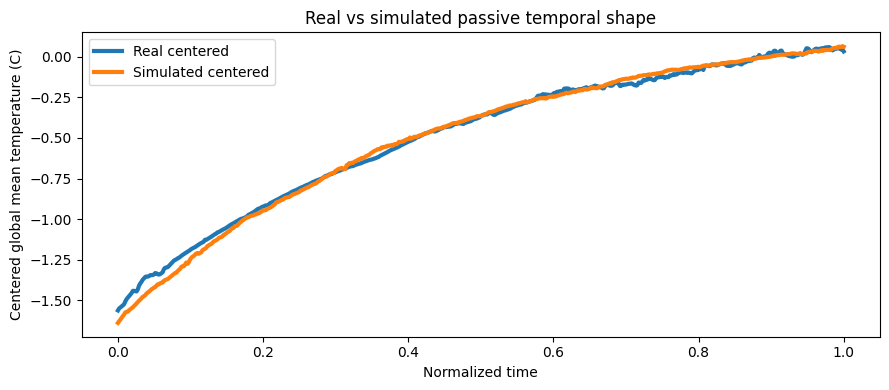

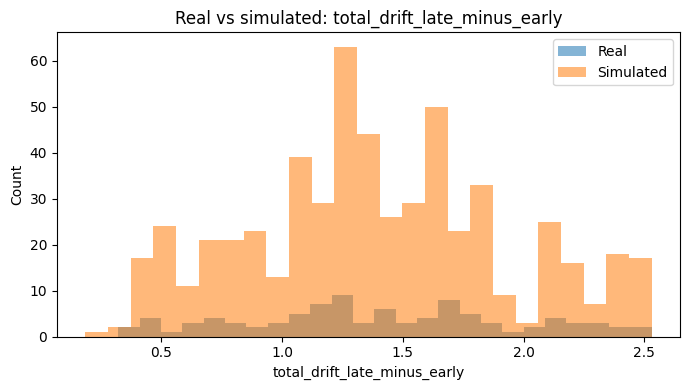

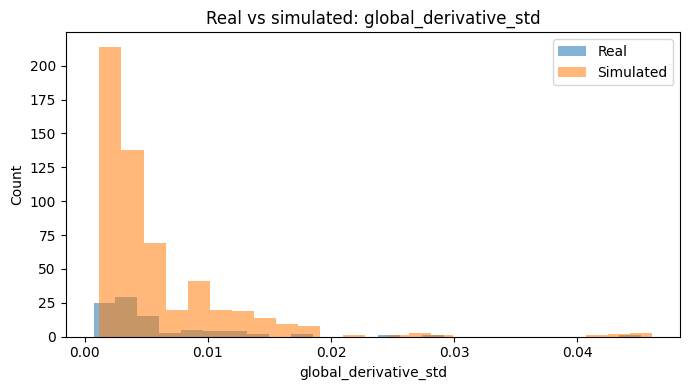

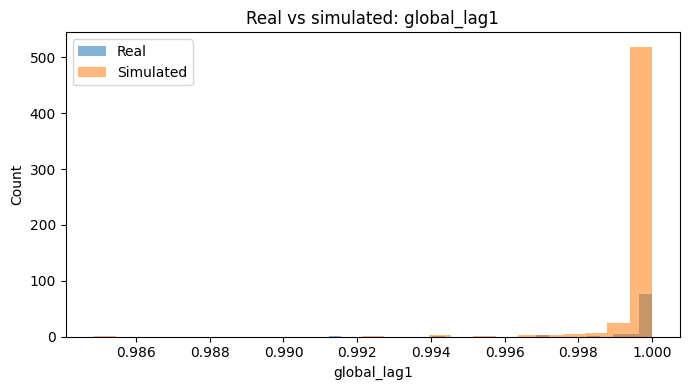

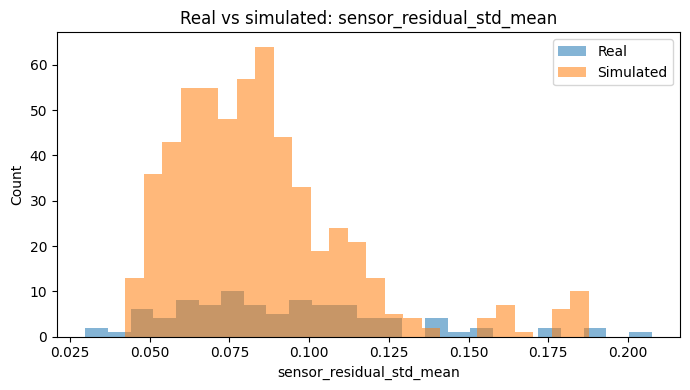

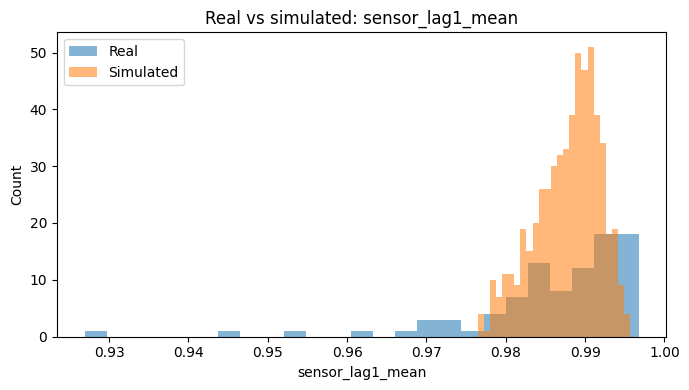

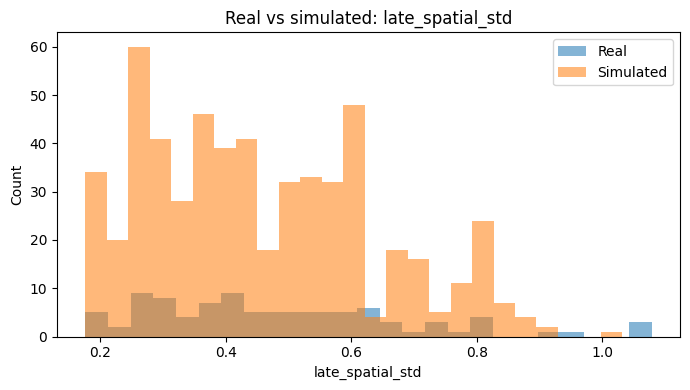

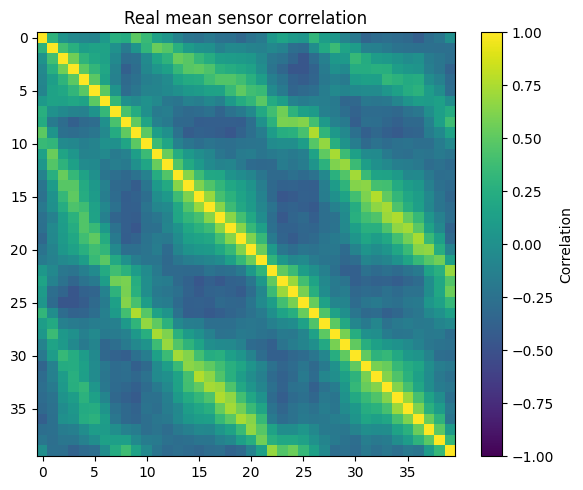

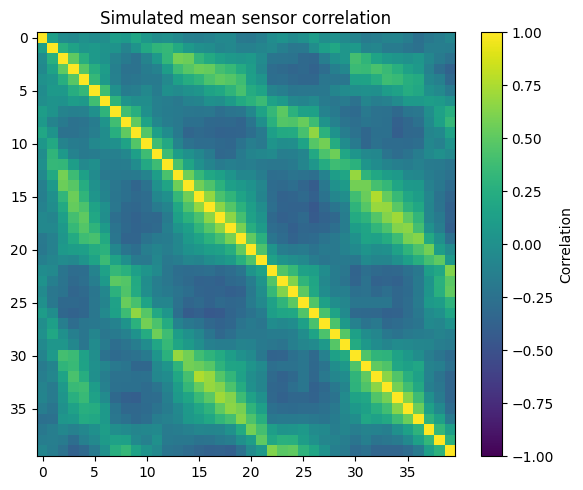

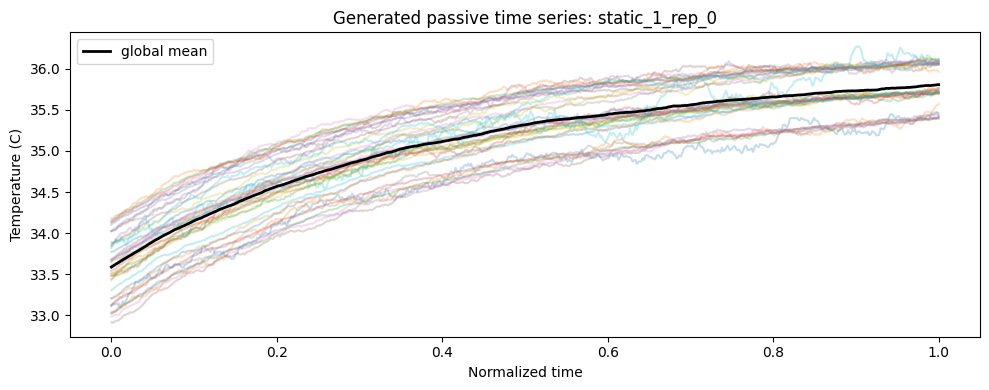

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


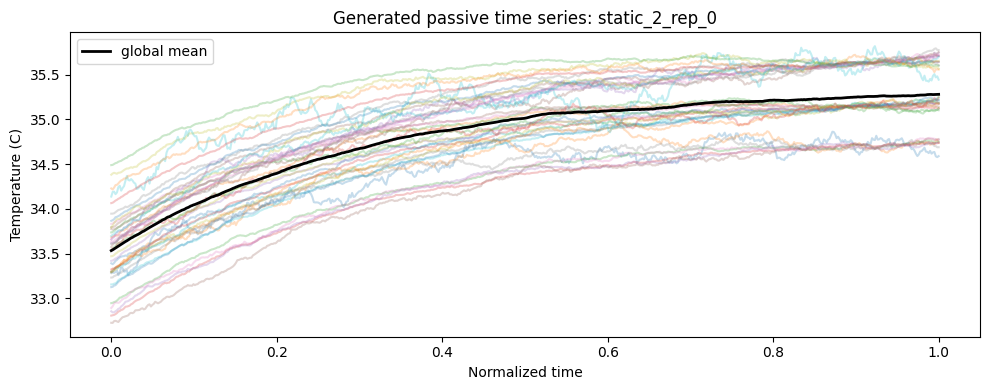

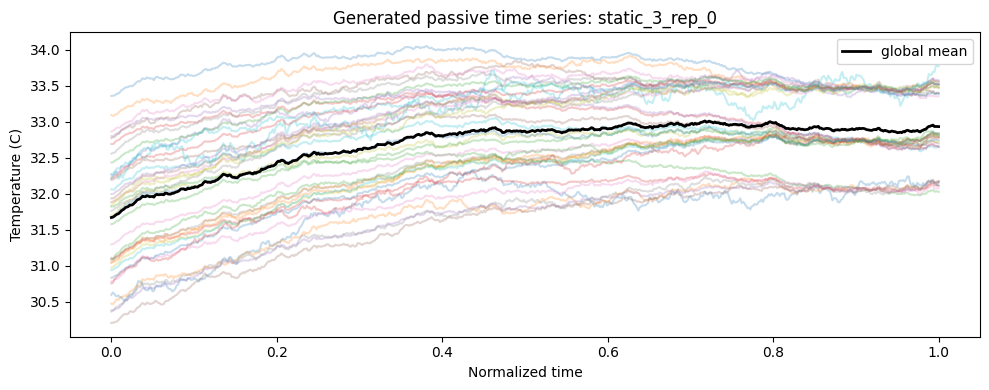

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


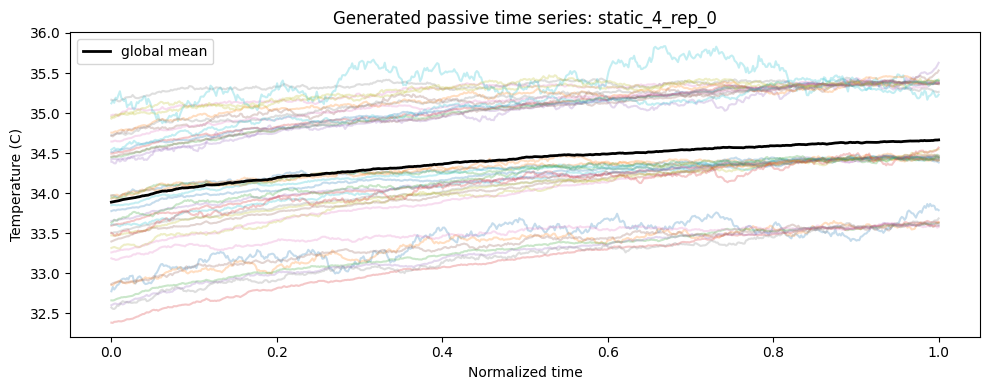

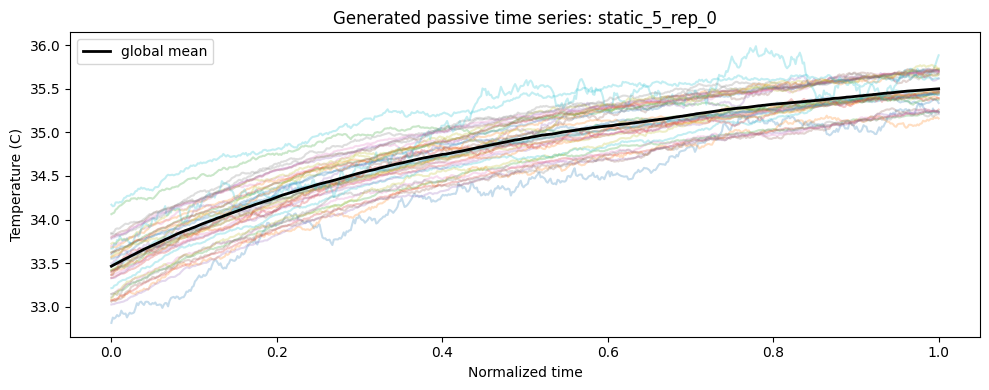

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


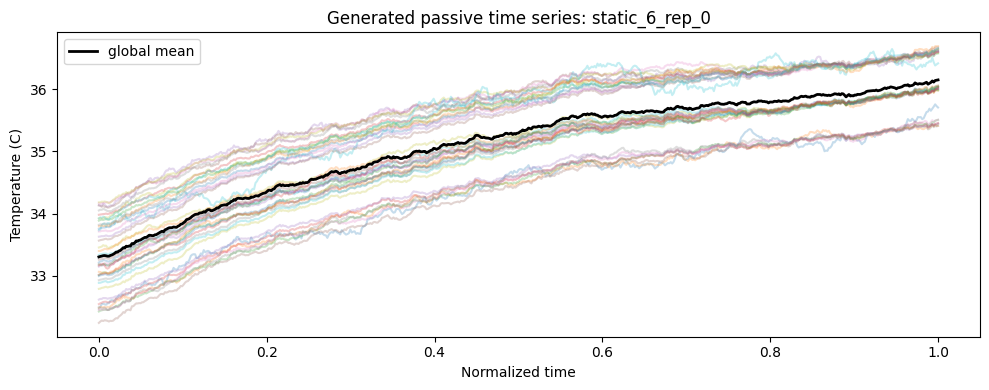

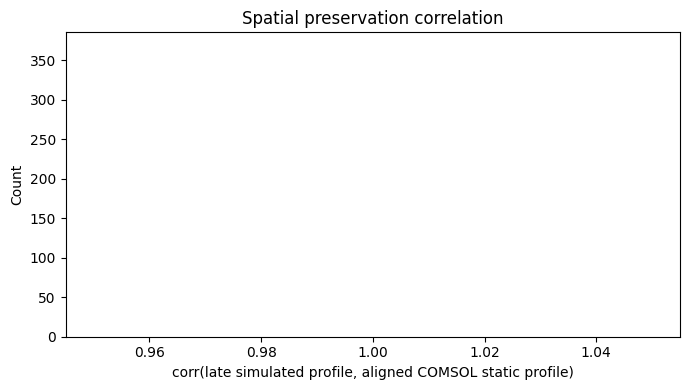

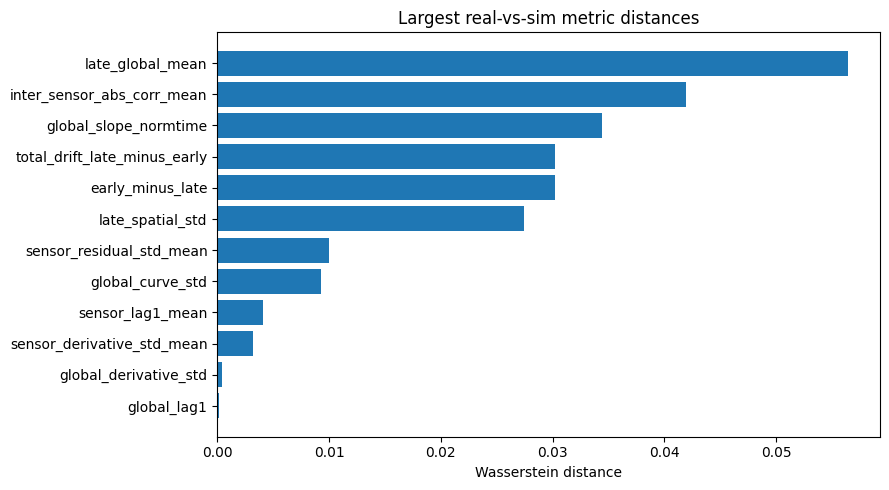

In [35]:
plt.figure(figsize=(9,4))
plt.plot(T_NORM, REAL_MEDIAN_GLOBAL_CURVE, linewidth=3, label="Real median global curve")
plt.plot(T_NORM, SIM_MEDIAN_GLOBAL_CURVE, linewidth=3, label="Simulated median global curve")
plt.xlabel("Normalized time")
plt.ylabel("Global mean temperature (C)")
plt.title("Real vs simulated global mean curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "real_vs_simulated_median_global_curve_absolute.png", dpi=CFG.figure_dpi)
plt.show()

plt.figure(figsize=(9,4))
plt.plot(T_NORM, real_centered, linewidth=3, label="Real centered")
plt.plot(T_NORM, sim_centered, linewidth=3, label="Simulated centered")
plt.xlabel("Normalized time")
plt.ylabel("Centered global mean temperature (C)")
plt.title("Real vs simulated passive temporal shape")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "real_vs_simulated_median_global_curve_centered.png", dpi=CFG.figure_dpi)
plt.show()

for metric in [
    "total_drift_late_minus_early",
    "global_derivative_std",
    "global_lag1",
    "sensor_residual_std_mean",
    "sensor_lag1_mean",
    "late_spatial_std",
]:
    plt.figure(figsize=(7,4))
    plt.hist(real_metrics[metric].dropna(), bins=25, alpha=0.55, label="Real")
    plt.hist(sim_metrics[metric].dropna(), bins=25, alpha=0.55, label="Simulated")
    plt.xlabel(metric)
    plt.ylabel("Count")
    plt.title(f"Real vs simulated: {metric}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"dist_compare_{metric}.png", dpi=CFG.figure_dpi)
    plt.show()

plt.figure(figsize=(6,5))
plt.imshow(REAL_MEAN_CORR, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Real mean sensor correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "real_mean_sensor_correlation.png", dpi=CFG.figure_dpi)
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(SIM_MEAN_CORR, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Simulated mean sensor correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "simulated_mean_sensor_correlation.png", dpi=CFG.figure_dpi)
plt.show()

for gid in generation_info["generated_id"].head(6):
    g = generated_long[generated_long["generated_id"] == gid]
    X = g[SENSOR_COLS].to_numpy(dtype=float)
    plt.figure(figsize=(10,4))
    for j in range(CFG.n_sensors):
        plt.plot(g["norm_time"], X[:, j], alpha=0.25)
    plt.plot(g["norm_time"], X.mean(axis=1), color="black", linewidth=2, label="global mean")
    plt.xlabel("Normalized time")
    plt.ylabel("Temperature (C)")
    plt.title(f"Generated passive time series: {gid}")
    plt.legend()
    plt.tight_layout()
    safe_gid = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(gid))
    plt.savefig(FIG_DIR / f"generated_sample_curves_{safe_gid}.png", dpi=CFG.figure_dpi)
    plt.show()

plt.figure(figsize=(7,4))
plt.hist(spatial_preservation["late_vs_aligned_static_corr"].dropna(), bins=30)
plt.xlabel("corr(late simulated profile, aligned COMSOL static profile)")
plt.ylabel("Count")
plt.title("Spatial preservation correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "spatial_preservation_correlation_distribution.png", dpi=CFG.figure_dpi)
plt.show()

if len(validation_comparison):
    top = validation_comparison.sort_values("wasserstein", ascending=False).head(12)
    plt.figure(figsize=(9,5))
    plt.barh(top["metric"], top["wasserstein"])
    plt.gca().invert_yaxis()
    plt.xlabel("Wasserstein distance")
    plt.title("Largest real-vs-sim metric distances")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "largest_validation_wasserstein_distances.png", dpi=CFG.figure_dpi)
    plt.show()

## 15) Condition-aware validation

In [36]:
condition_rows = []
for cond in sorted(set(real_metrics["label"].astype(str)).intersection(set(sim_metrics["label"].astype(str)))):
    rsub = real_metrics[real_metrics["label"].astype(str) == cond]
    ssub = sim_metrics[sim_metrics["label"].astype(str) == cond]
    if len(rsub) < 3 or len(ssub) < 3:
        continue
    for metric in METRICS_TO_COMPARE:
        r = rsub[metric].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
        s = ssub[metric].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
        if len(r) == 0 or len(s) == 0:
            continue
        ks = ks_2samp(r, s)
        condition_rows.append({
            "condition": cond,
            "metric": metric,
            "n_real": len(r),
            "n_sim": len(s),
            "real_mean": float(np.nanmean(r)),
            "sim_mean": float(np.nanmean(s)),
            "wasserstein": float(wasserstein_distance(r, s)),
            "ks_statistic": float(ks.statistic),
            "ks_pvalue": float(ks.pvalue),
        })
condition_validation = pd.DataFrame(condition_rows)
condition_validation.to_csv(VALIDATION_DIR / "condition_aware_real_vs_simulated_validation.csv", index=False)

if len(condition_validation):
    display(condition_validation.sort_values(["condition", "wasserstein"], ascending=[True, False]).head(40))
else:
    print("Condition-aware validation skipped due to insufficient groups.")

,condition,metric,n_real,n_sim,real_mean,sim_mean,wasserstein,ks_statistic,ks_pvalue
11,Healthy,inter_sensor_abs_corr_mean,60,228,0.642205,0.581098,0.061321,0.279825,8.935493e-04
0,Healthy,late_global_mean,60,228,34.882613,34.894621,0.042427,0.056140,9.960860e-01
10,Healthy,late_spatial_std,60,228,0.475279,0.439165,0.036115,0.082456,8.748183e-01
3,Healthy,global_slope_normtime,60,228,1.538259,1.512928,0.035436,0.072807,9.455955e-01
2,Healthy,early_minus_late,60,228,-1.425652,-1.398545,0.034320,0.064912,9.797986e-01
1,Healthy,total_drift_late_minus_early,60,228,1.425652,1.398545,0.034320,0.064912,9.797986e-01
4,Healthy,global_curve_std,60,228,0.462262,0.455744,0.009431,0.072807,9.455955e-01
7,Healthy,sensor_residual_std_mean,60,228,0.090757,0.086076,0.007287,0.111404,5.572852e-01
9,Healthy,sensor_lag1_mean,60,228,0.985610,0.986956,0.004425,0.243860,5.707237e-03
8,Healthy,sensor_derivative_std_mean,60,228,0.010643,0.012028,0.003529,0.683333,5.849086e-22


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 16) QA checks

In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# 16) QA checks — stricter scientific validation gate
# ═══════════════════════════════════════════════════════════════════════════════

qa_checks = []


def add_check(name, value, passed, severity, note):
    qa_checks.append({
        "check": name,
        "value": float(value) if isinstance(value, (int, float, np.floating, np.integer)) and np.isfinite(value) else value,
        "passed": bool(passed),
        "severity": severity,
        "note": note,
    })


def metric_mean(metric, df):
    vals = df[metric].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    return float(np.nanmean(vals)) if len(vals) else np.nan


def metric_ratio(metric):
    r = metric_mean(metric, real_metrics)
    s = metric_mean(metric, sim_metrics)
    if not np.isfinite(r) or abs(r) < 1e-12:
        return np.nan
    return float(s / r)


def metric_absdiff(metric):
    r = metric_mean(metric, real_metrics)
    s = metric_mean(metric, sim_metrics)
    if not np.isfinite(r) or not np.isfinite(s):
        return np.nan
    return float(abs(s - r))


sensor_array = generated_long[SENSOR_COLS].to_numpy(dtype=float)

# Critical sanity checks
add_check(
    "no_nan_in_generated_sensor_values",
    float(np.isnan(sensor_array).mean()),
    not np.isnan(sensor_array).any(),
    "critical",
    "Generated sensor table must not contain NaN."
)

add_check(
    "below_20C_rate",
    validation_summary["pct_generated_below_20C"],
    validation_summary["pct_generated_below_20C"] <= 1e-4,
    "critical",
    "Clean simulator should not generate contact-loss temperatures below 20 C."
)

add_check(
    "above_45C_rate",
    validation_summary["pct_generated_above_45C"],
    validation_summary["pct_generated_above_45C"] <= 1e-4,
    "critical",
    "Clean simulator should not generate temperatures above 45 C."
)

# Spatial preservation
add_check(
    "spatial_preservation_corr",
    validation_summary["median_spatial_preservation_corr"],
    validation_summary["median_spatial_preservation_corr"] >= 0.90
    or np.isnan(validation_summary["median_spatial_preservation_corr"]),
    "high",
    "Late simulated spatial profile should preserve aligned COMSOL profile."
)

# Global passive trend
add_check(
    "global_curve_centered_corr",
    validation_summary["global_curve_centered_corr"],
    validation_summary["global_curve_centered_corr"] >= 0.95
    or np.isnan(validation_summary["global_curve_centered_corr"]),
    "high",
    "Centered simulated global curve should match real median passive curve."
)

add_check(
    "global_curve_centered_rmse",
    validation_summary["global_curve_centered_rmse"],
    validation_summary["global_curve_centered_rmse"] <= 0.10
    or np.isnan(validation_summary["global_curve_centered_rmse"]),
    "medium",
    "Centered simulated global curve RMSE should remain small."
)

# Newly strict simulator-realism checks
late_spatial_ratio = metric_ratio("late_spatial_std")
add_check(
    "late_spatial_std_ratio",
    late_spatial_ratio,
    np.isfinite(late_spatial_ratio) and 0.80 <= late_spatial_ratio <= 1.25,
    "high",
    "Simulated late spatial spread should match real spatial sensor variability."
)

corr_diff = metric_absdiff("inter_sensor_abs_corr_mean")
add_check(
    "inter_sensor_correlation_absdiff",
    corr_diff,
    np.isfinite(corr_diff) and corr_diff <= 0.10,
    "high",
    "Simulated inter-sensor correlation should be close to real CBRA correlation."
)

deriv_ratio = metric_ratio("sensor_derivative_std_mean")
add_check(
    "sensor_derivative_std_ratio",
    deriv_ratio,
    np.isfinite(deriv_ratio) and 0.75 <= deriv_ratio <= 1.25,
    "high",
    "Sensor-level frame-to-frame variation should not be too sharp or too smooth."
)

lag1_diff = metric_absdiff("sensor_lag1_mean")
add_check(
    "sensor_lag1_mean_absdiff",
    lag1_diff,
    np.isfinite(lag1_diff) and lag1_diff <= 0.005,
    "medium",
    "Mean lag-1 autocorrelation should match real temporal smoothness."
)

residual_ratio = metric_ratio("sensor_residual_std_mean")
add_check(
    "sensor_residual_std_ratio",
    residual_ratio,
    np.isfinite(residual_ratio) and 0.70 <= residual_ratio <= 1.35,
    "medium",
    "Residual sensor variability should be reasonably close to real data."
)

drift_ratio = metric_ratio("total_drift_late_minus_early")
add_check(
    "total_drift_ratio",
    drift_ratio,
    np.isfinite(drift_ratio) and 0.75 <= drift_ratio <= 1.30,
    "medium",
    "Total passive drift should match real drift distribution."
)

qa_table = pd.DataFrame(qa_checks)
qa_table.to_csv(TEST_DIR / "simulator_qa_checks.csv", index=False)
display(qa_table)

n_critical_fail = int(((qa_table["severity"] == "critical") & (~qa_table["passed"])).sum())
n_high_fail = int(((qa_table["severity"] == "high") & (~qa_table["passed"])).sum())
n_medium_fail = int(((qa_table["severity"] == "medium") & (~qa_table["passed"])).sum())

if n_critical_fail > 0:
    proceed_status = "FAIL_CRITICAL"
elif n_high_fail > 0:
    proceed_status = "PARTIAL_PASS_HIGH_ISSUES"
elif n_medium_fail > 0:
    proceed_status = "PASS_WITH_MEDIUM_WARNINGS"
else:
    proceed_status = "PASS_STRICT"

gate_summary = {
    "n_checks": int(len(qa_table)),
    "n_failed": int((~qa_table["passed"]).sum()),
    "n_critical_failed": n_critical_fail,
    "n_high_failed": n_high_fail,
    "n_medium_failed": n_medium_fail,
    "proceed_status": proceed_status,
    "interpretation": (
        "PASS_STRICT means the simulator matches real CBRA temporal and spatial statistics sufficiently for this stage. "
        "PARTIAL_PASS_HIGH_ISSUES means generation works but spatial/noise realism still needs correction."
    )
}

save_json(gate_summary, TEST_DIR / "qa_gate_summary.json")
print(json.dumps(gate_summary, indent=2))

,check,value,passed,severity,note
0,no_nan_in_generated_sensor_values,0.000000,True,critical,Generated sensor table must not contain NaN.
1,below_20C_rate,0.000000,True,critical,Clean simulator should not generate contact-lo...
2,above_45C_rate,0.000000,True,critical,Clean simulator should not generate temperatur...
3,spatial_preservation_corr,1.000000,True,high,Late simulated spatial profile should preserve...
4,global_curve_centered_corr,0.998738,True,high,Centered simulated global curve should match r...
5,global_curve_centered_rmse,0.033408,True,medium,Centered simulated global curve RMSE should re...
6,late_spatial_std_ratio,0.943441,True,high,Simulated late spatial spread should match rea...
7,inter_sensor_correlation_absdiff,0.041934,True,high,Simulated inter-sensor correlation should be c...
8,sensor_derivative_std_ratio,1.035480,True,high,Sensor-level frame-to-frame variation should n...
9,sensor_lag1_mean_absdiff,0.001959,True,medium,Mean lag-1 autocorrelation should match real t...


{
  "n_checks": 12,
  "n_failed": 0,
  "n_critical_failed": 0,
  "n_high_failed": 0,
  "n_medium_failed": 0,
  "proceed_status": "PASS_STRICT",
  "interpretation": "PASS_STRICT means the simulator matches real CBRA temporal and spatial statistics sufficiently for this stage. PARTIAL_PASS_HIGH_ISSUES means generation works but spatial/noise realism still needs correction."
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 17) Artifact index and report-ready run summary

In [38]:
artifact_index = {
    "config": {
        "simulator_config": str(CONFIG_DIR / "simulator_config.json"),
        "scientific_grounding_register": str(CONFIG_DIR / "scientific_grounding_register.csv"),
        "sensor_graph_W": str(CONFIG_DIR / "sensor_graph_W.npy"),
        "sensor_graph_L": str(CONFIG_DIR / "sensor_graph_L.npy"),
    },
    "audit": {
        "data_audit_summary": str(AUDIT_DIR / "data_audit_summary.json"),
        "real_session_side_audit": str(AUDIT_DIR / "real_session_side_audit.csv"),
        "comsol_static_audit": str(AUDIT_DIR / "comsol_static_audit.json"),
    },
    "calibration": {
        "calibration_root": str(CALIB_DIR),
        "per_group_temporal_basis": "01_temporal_calibration/<group>/temporal_basis.csv",
        "per_group_session_parameters": "01_temporal_calibration/<group>/calibrated_session_parameters.csv",
    },
    "generated": {
        "generated_long_csv_gz": str(GENERATED_DIR / "calibrated_passive_generated_timeseries_long.csv.gz"),
        "generated_long_parquet": str(GENERATED_DIR / "calibrated_passive_generated_timeseries_long.parquet"),
        "generated_tensor": str(GENERATED_DIR / "generated_tensor_samples_time_sensors.npy"),
        "generation_parameters": str(GENERATED_DIR / "generation_parameters_per_sample.csv"),
    },
    "validation": {
        "real_metrics": str(VALIDATION_DIR / "real_temporal_validation_metrics.csv"),
        "simulated_metrics": str(VALIDATION_DIR / "simulated_temporal_validation_metrics.csv"),
        "metric_distribution_comparison": str(VALIDATION_DIR / "real_vs_simulated_metric_distribution_comparison.csv"),
        "validation_summary": str(VALIDATION_DIR / "validation_summary.json"),
        "spatial_preservation_metrics": str(VALIDATION_DIR / "spatial_preservation_metrics.csv"),
    },
    "qa": {
        "qa_checks": str(TEST_DIR / "simulator_qa_checks.csv"),
        "qa_gate_summary": str(TEST_DIR / "qa_gate_summary.json"),
    },
    "figures": str(FIG_DIR),
}
save_json(artifact_index, OUTPUT_DIR / "artifact_index.json")

summary_md = f'''# Calibrated passive static-to-time-series simulator summary

## Objective

Generate calibrated passive 40-sensor CBRA-like time series from static COMSOL breast thermography samples.

## Scientific framing

The generated time series are not a full transient physiological simulation. They are empirical passive temporal overlays calibrated from real CBRA recordings and anchored on COMSOL/Pennes static spatial baselines.

## Main simulator equation

T_sim_i(t) = T_static'_i + A*g(t) + b*p(t) + d_i*p(t) + eta(t) + eps_i(t)

## Generated data

- Static COMSOL rows used: {len(static_rows)}
- Replicates per static row: {CFG.samples_per_static_row}
- Generated sessions: {len(generation_info)}
- Time steps per session: {N_TIME}
- Long table rows: {len(generated_long)}

## Validation summary

```json
{json.dumps(validation_summary, indent=2)}
```

## QA gate

```json
{json.dumps(gate_summary, indent=2)}
```

## Important limitation

This simulator validates statistical similarity of passive temporal behavior, not diagnostic performance. Classification is intentionally outside this notebook.
'''

with open(OUTPUT_DIR / "run_summary.md", "w", encoding="utf-8") as f:
    f.write(summary_md)

print(summary_md)
print("Artifact index:", OUTPUT_DIR / "artifact_index.json")

# Calibrated passive static-to-time-series simulator summary

## Objective

Generate calibrated passive 40-sensor CBRA-like time series from static COMSOL breast thermography samples.

## Scientific framing

The generated time series are not a full transient physiological simulation. They are empirical passive temporal overlays calibrated from real CBRA recordings and anchored on COMSOL/Pennes static spatial baselines.

## Main simulator equation

T_sim_i(t) = T_static'_i + A*g(t) + b*p(t) + d_i*p(t) + eta(t) + eps_i(t)

## Generated data

- Static COMSOL rows used: 564
- Replicates per static row: 1
- Generated sessions: 564
- Time steps per session: 585
- Long table rows: 329940

## Validation summary

```json
{
  "n_real_sessions": 92,
  "n_simulated_sessions": 564,
  "n_generated_long_rows": 329940,
  "global_curve_centered_rmse": 0.033407808275951766,
  "global_curve_centered_corr": 0.998737975332833,
  "sensor_correlation_matrix_frobenius_per_sensor": 0.07710523239401895,
  "medi

## 18) Interpretation after running

Check these first:

1. `05_tests/qa_gate_summary.json`
2. `03_validation/validation_summary.json`
3. `03_validation/real_vs_simulated_metric_distribution_comparison.csv`
4. plots in `04_figures/`

If validation is weak, tune only empirical simulator parameters:

- `simulator_noise_multiplier`
- `simulator_drift_multiplier`
- `static_alignment_mode`
- condition-aware vs global calibration
- covariance shrinkage

Do not add classification metrics here. Classification belongs to a later phase after simulator validation.